In [1]:
import os

import coiled
import matplotlib.pyplot as plt
import xarray as xr
from frisky import hijack

from srm.qa_flags import (
    DIR_QA_FLAG_CONSTANT_INPUTS,
    calculate_thresholds,
    discover_leaves,
    flag_global_exceedances,
    flag_outliers,
    flag_rsds_above_max,
    run_flag_loop,
)

os.environ["FRISKY_SUMMARY"] = "off"

In [2]:
VARIABLES = ["tas", "tasmax", "tasmin", "pr", "rsds"]
METHODS = ["bcsd", "qdmsd"]
GCMS = ["CESM2-WACCM6", "UKESM1-1-LL"]

BRANCH = "v0.14.1"
ROOT_DIR = "s3://us-west-2.opendata.source.coop/carbonplan/srm-downscaling/output/production/"
STORE_SUBSET_ID = "global"

PLOT_FLAG_MAPS = True
BUCKET = "carbonplan-srm"
PREFIX = "scratch/output/qa-intermediate-flags-v0.14.1"

In [7]:
import logging

logging.basicConfig(level=logging.INFO)

## Set up cluster

In [3]:
cluster = coiled.Cluster(
    name="srm-qaqc-flags-nrh",
    region="us-west-2",
    n_workers=12,
    worker_vm_types=["m8gn.xlarge"],
    scheduler_vm_types="c8g.xlarge",
    spot_policy="spot_with_fallback",
    use_best_zone=True,
    tags={"Project": "SRM"},
    worker_options={"nthreads": 8},
    environ={"ZARR_ASYNC__CONCURRENCY": "128"},
)

client = hijack(cluster.get_client())
client

[2026-09-08 22:55:18,571][INFO    ][coiled] Using existing cluster: 'srm-qaqc-flags-nrh (id: 2024676)'
[2026-09-08 22:55:18,572][INFO    ][coiled] Attaching to existing cluster (name: srm-qaqc-flags-nrh, https://cloud.coiled.io/clusters/2024676 )


<frisky.Client: scheduler="wss://cluster-inlzn.dask.host/k_opjXBJSbz1UI9W/frisky-comm?__frisky_dial_host=44.243.169.199" id="client-0">

# Option 1: call `run_step2` function (goes through all steps at once, for both downscaled and debiased coarse)

In [4]:
from srm.qa_flags import run_step2

INFO:srm.qa_flags:Discovering leaves of the data tree...
/Users/clairezarakas/Documents/science/srm-downscaling/src/srm/qa_flags.py:1440: UserWarning: The specified chunks separate the stored chunks along dimension "lat" starting at index 180. This could degrade performance. Instead, consider rechunking after loading.
  trees[gcm] = xr.open_datatree(session.store, engine="zarr", chunks=INPUT_CHUNKS)
/Users/clairezarakas/Documents/science/srm-downscaling/src/srm/qa_flags.py:1440: UserWarning: The specified chunks separate the stored chunks along dimension "lon" starting at index 360. This could degrade performance. Instead, consider rechunking after loading.
  trees[gcm] = xr.open_datatree(session.store, engine="zarr", chunks=INPUT_CHUNKS)
/Users/clairezarakas/Documents/science/srm-downscaling/src/srm/qa_flags.py:1440: UserWarning: The specified chunks separate the stored chunks along dimension "lat" starting at index 180. This could degrade performance. Instead, consider rechunking aft

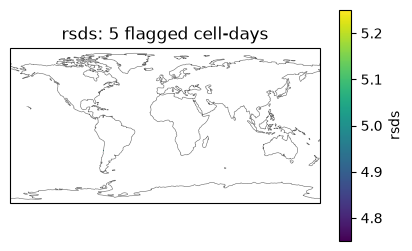

INFO:srm.qa_flags:CESM2-WACCM6_rsds_g6_1p5k_003_qdmsd
INFO:srm.qa_flags:No flags found.
INFO:srm.qa_flags:CESM2-WACCM6_pr_g6_1p5k_002_qdmsd
INFO:srm.qa_flags:No flags found.
INFO:srm.qa_flags:CESM2-WACCM6_pr_g6_1p5k_003_qdmsd
INFO:srm.qa_flags:No flags found.
INFO:srm.qa_flags:CESM2-WACCM6_tasmin_g6_1p5k_002_qdmsd
INFO:srm.qa_flags:No flags found.
INFO:srm.qa_flags:CESM2-WACCM6_tasmin_g6_1p5k_003_qdmsd
INFO:srm.qa_flags:No flags found.
INFO:srm.qa_flags:CESM2-WACCM6_tasmax_g6_1p5k_002_qdmsd
INFO:srm.qa_flags:No flags found.
INFO:srm.qa_flags:CESM2-WACCM6_tasmax_g6_1p5k_003_qdmsd
INFO:srm.qa_flags:No flags found.
INFO:srm.qa_flags:CESM2-WACCM6_tas_g6_1p5k_002_qdmsd
INFO:srm.qa_flags:No flags found.
INFO:srm.qa_flags:CESM2-WACCM6_tas_g6_1p5k_003_qdmsd
INFO:srm.qa_flags:No flags found.
INFO:srm.qa_flags:CESM2-WACCM6_tasmax_historical_001_qdmsd
INFO:srm.qa_flags:No flags found.
INFO:srm.qa_flags:CESM2-WACCM6_tasmin_historical_001_qdmsd
INFO:srm.qa_flags:No flags found.
INFO:srm.qa_flags:CE

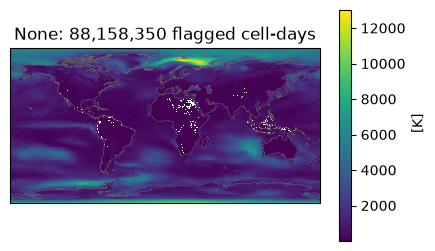

INFO:srm.qa_flags:CESM2-WACCM6_tas_g6_1p5k_003_bcsd


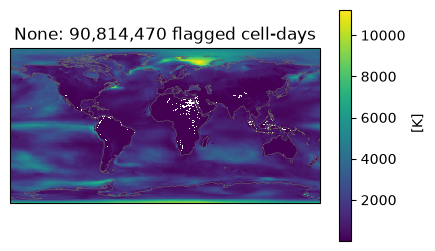

INFO:srm.qa_flags:CESM2-WACCM6_tas_g6_1p5k_end_002_bcsd


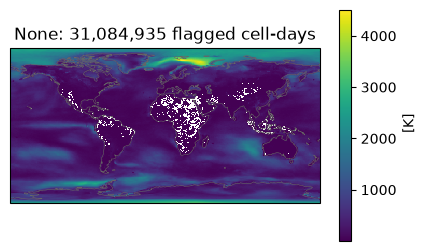

INFO:srm.qa_flags:CESM2-WACCM6_tas_ssp245_008_bcsd


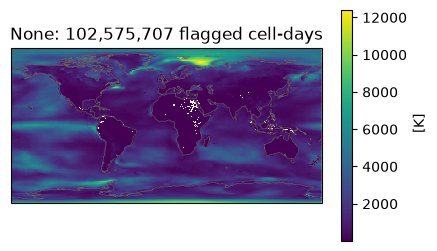

INFO:srm.qa_flags:CESM2-WACCM6_tas_g6_1p5k_002_qdmsd


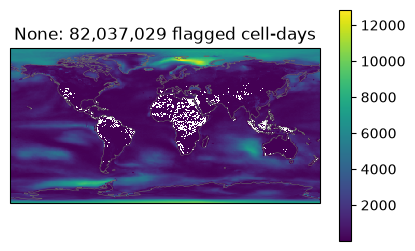

INFO:srm.qa_flags:CESM2-WACCM6_tas_g6_1p5k_003_qdmsd


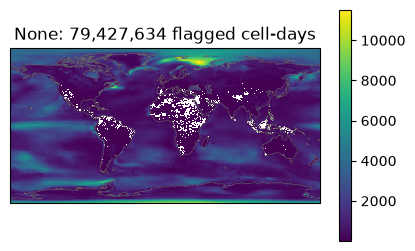

INFO:srm.qa_flags:CESM2-WACCM6_tas_ssp245_008_qdmsd


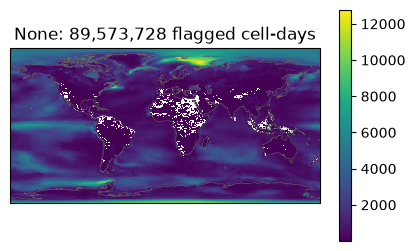

INFO:srm.qa_flags:CESM2-WACCM6_tas_g6_1p5k_end_002_qdmsd


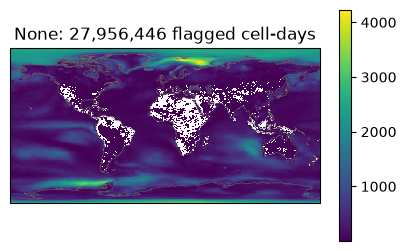

INFO:srm.qa_flags:  flag loop 2/5 completed in 158.4s
INFO:srm.qa_flags:Running flag loop 3/5: annual outlier flag...
INFO:aiobotocore.credentials:Found credentials in shared credentials file: ~/.aws/credentials
INFO:srm.qa_flags:62 tags to process
INFO:srm.qa_flags:CESM2-WACCM6_rsds_g6_1p5k_002_bcsd
INFO:srm.qa_flags:No flags found.
INFO:srm.qa_flags:CESM2-WACCM6_rsds_g6_1p5k_003_bcsd
INFO:srm.qa_flags:No flags found.
INFO:srm.qa_flags:CESM2-WACCM6_tas_g6_1p5k_002_bcsd


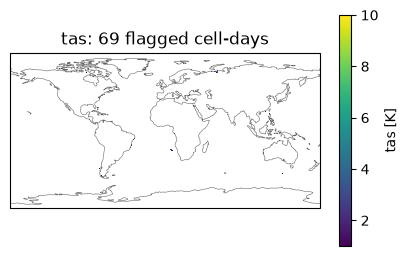

INFO:srm.qa_flags:CESM2-WACCM6_tas_g6_1p5k_003_bcsd


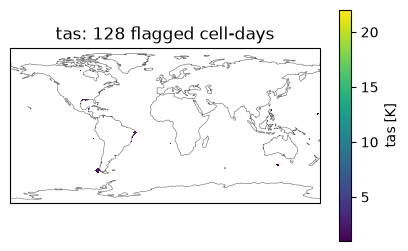

INFO:srm.qa_flags:CESM2-WACCM6_tasmin_g6_1p5k_002_bcsd


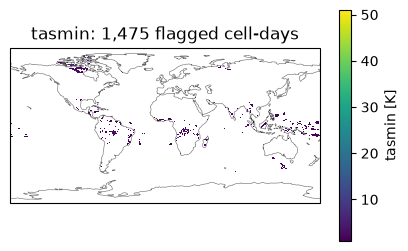

INFO:srm.qa_flags:CESM2-WACCM6_tasmin_g6_1p5k_003_bcsd


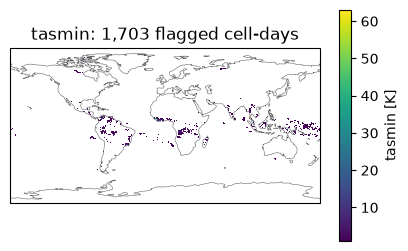

INFO:srm.qa_flags:CESM2-WACCM6_pr_g6_1p5k_002_bcsd


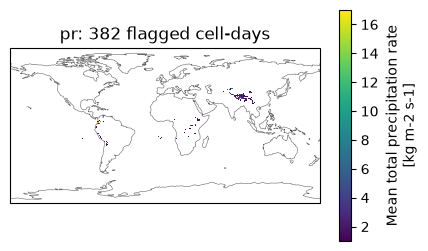

INFO:srm.qa_flags:CESM2-WACCM6_pr_g6_1p5k_003_bcsd


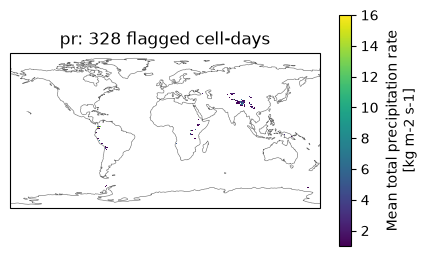

INFO:srm.qa_flags:CESM2-WACCM6_tasmax_g6_1p5k_002_bcsd


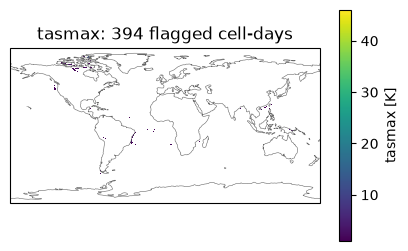

INFO:srm.qa_flags:CESM2-WACCM6_tasmax_g6_1p5k_003_bcsd


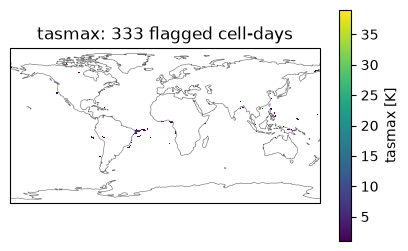

INFO:srm.qa_flags:CESM2-WACCM6_tas_historical_r2i1p1f1_bcsd
INFO:srm.qa_flags:No flags found.
INFO:srm.qa_flags:CESM2-WACCM6_tas_historical_r3i1p1f1_bcsd
INFO:srm.qa_flags:No flags found.
INFO:srm.qa_flags:CESM2-WACCM6_rsds_historical_r2i1p1f1_bcsd
INFO:srm.qa_flags:No flags found.
INFO:srm.qa_flags:CESM2-WACCM6_rsds_historical_r3i1p1f1_bcsd
INFO:srm.qa_flags:No flags found.
INFO:srm.qa_flags:CESM2-WACCM6_tasmin_historical_001_bcsd


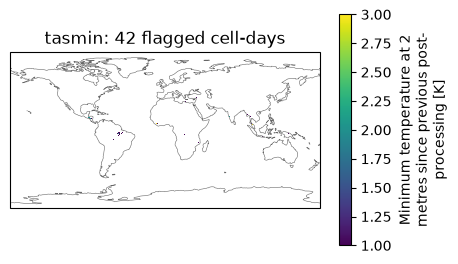

INFO:srm.qa_flags:CESM2-WACCM6_pr_historical_r2i1p1f1_bcsd
INFO:srm.qa_flags:No flags found.
INFO:srm.qa_flags:CESM2-WACCM6_pr_historical_r3i1p1f1_bcsd
INFO:srm.qa_flags:No flags found.
INFO:srm.qa_flags:CESM2-WACCM6_tasmax_historical_001_bcsd
INFO:srm.qa_flags:No flags found.
INFO:srm.qa_flags:CESM2-WACCM6_tas_g6_1p5k_end_002_bcsd


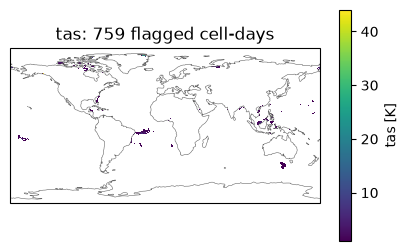

INFO:srm.qa_flags:CESM2-WACCM6_tasmin_g6_1p5k_end_002_bcsd


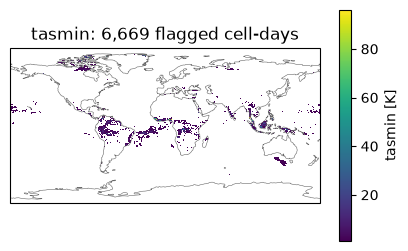

INFO:srm.qa_flags:CESM2-WACCM6_tasmax_g6_1p5k_end_002_bcsd


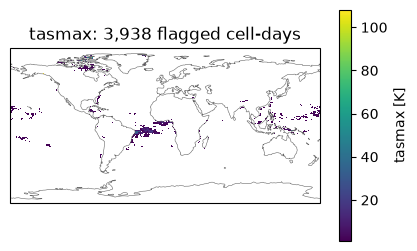

INFO:srm.qa_flags:CESM2-WACCM6_pr_g6_1p5k_end_002_bcsd


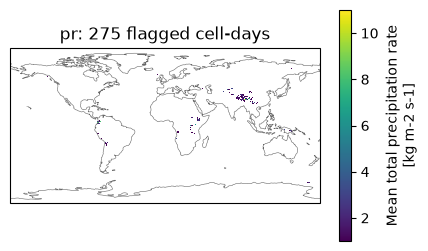

INFO:srm.qa_flags:CESM2-WACCM6_rsds_g6_1p5k_end_002_bcsd
INFO:srm.qa_flags:No flags found.
INFO:srm.qa_flags:CESM2-WACCM6_tas_ssp245_003_bcsd


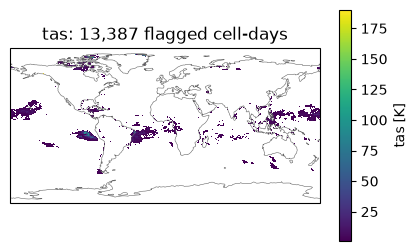

INFO:srm.qa_flags:CESM2-WACCM6_tas_ssp245_008_bcsd


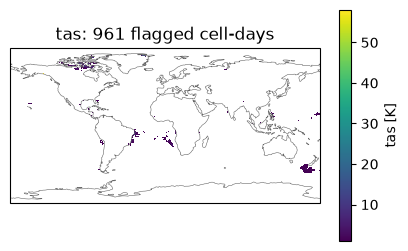

INFO:srm.qa_flags:CESM2-WACCM6_rsds_ssp245_003_bcsd
INFO:srm.qa_flags:No flags found.
INFO:srm.qa_flags:CESM2-WACCM6_rsds_ssp245_008_bcsd
INFO:srm.qa_flags:No flags found.
INFO:srm.qa_flags:CESM2-WACCM6_tasmin_ssp245_008_bcsd


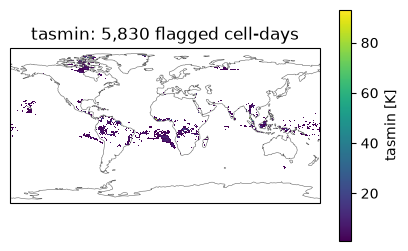

INFO:srm.qa_flags:CESM2-WACCM6_tasmax_ssp245_008_bcsd


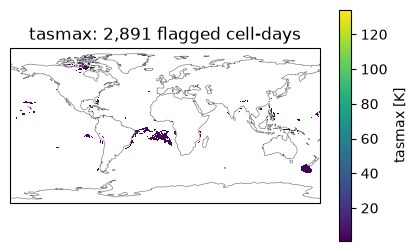

INFO:srm.qa_flags:CESM2-WACCM6_pr_ssp245_008_bcsd


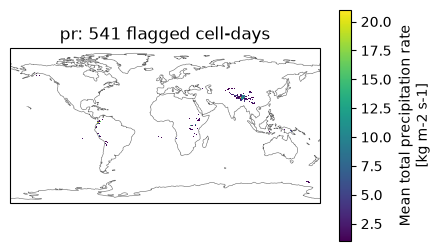

INFO:srm.qa_flags:CESM2-WACCM6_pr_ssp245_003_bcsd


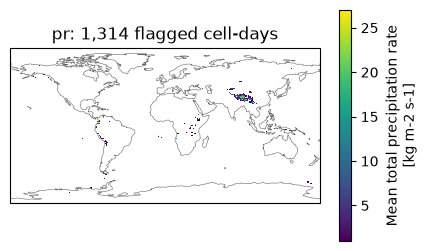

INFO:srm.qa_flags:CESM2-WACCM6_rsds_g6_1p5k_002_qdmsd


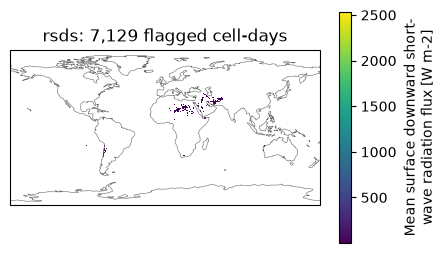

INFO:srm.qa_flags:CESM2-WACCM6_rsds_g6_1p5k_003_qdmsd


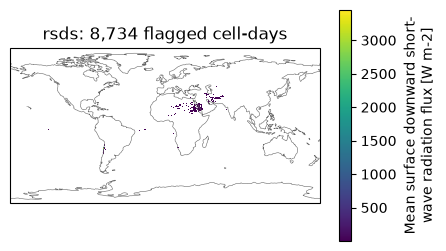

INFO:srm.qa_flags:CESM2-WACCM6_pr_g6_1p5k_002_qdmsd


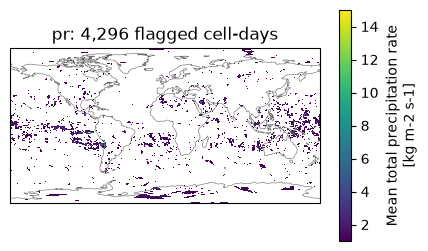

INFO:srm.qa_flags:CESM2-WACCM6_pr_g6_1p5k_003_qdmsd


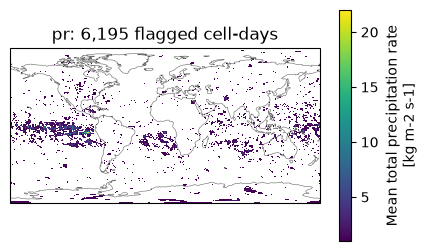

INFO:srm.qa_flags:CESM2-WACCM6_tasmin_g6_1p5k_002_qdmsd


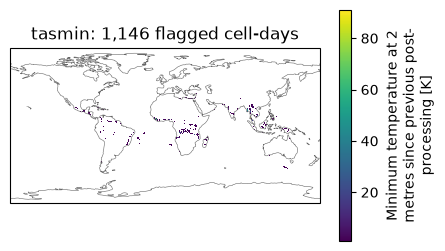

INFO:srm.qa_flags:CESM2-WACCM6_tasmin_g6_1p5k_003_qdmsd


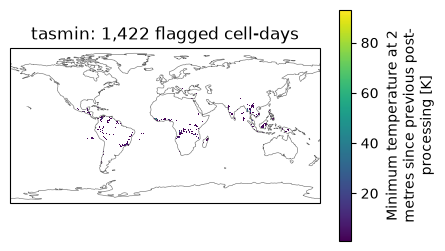

INFO:srm.qa_flags:CESM2-WACCM6_tasmax_g6_1p5k_002_qdmsd


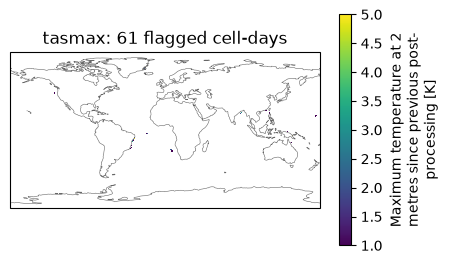

INFO:srm.qa_flags:CESM2-WACCM6_tasmax_g6_1p5k_003_qdmsd


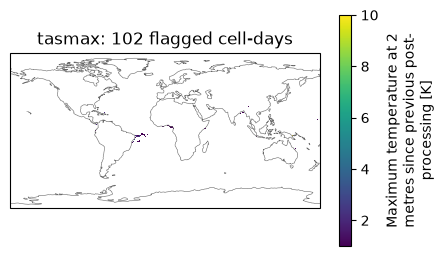

INFO:srm.qa_flags:CESM2-WACCM6_tas_g6_1p5k_002_qdmsd


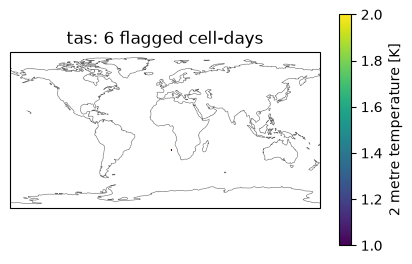

INFO:srm.qa_flags:CESM2-WACCM6_tas_g6_1p5k_003_qdmsd


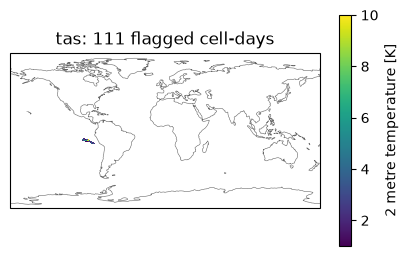

INFO:srm.qa_flags:CESM2-WACCM6_tasmax_historical_001_qdmsd
INFO:srm.qa_flags:No flags found.
INFO:srm.qa_flags:CESM2-WACCM6_tasmin_historical_001_qdmsd


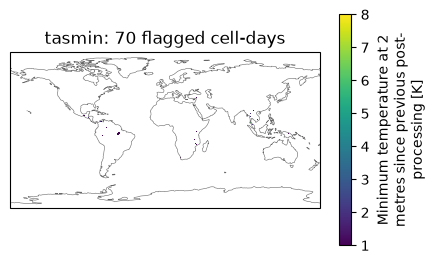

INFO:srm.qa_flags:CESM2-WACCM6_rsds_historical_r2i1p1f1_qdmsd


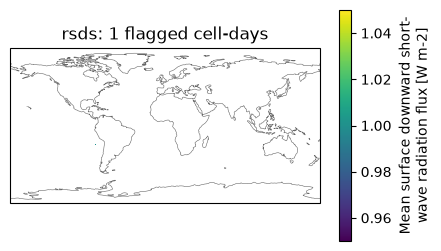

INFO:srm.qa_flags:CESM2-WACCM6_rsds_historical_r3i1p1f1_qdmsd
INFO:srm.qa_flags:No flags found.
INFO:srm.qa_flags:CESM2-WACCM6_pr_historical_r2i1p1f1_qdmsd
INFO:srm.qa_flags:No flags found.
INFO:srm.qa_flags:CESM2-WACCM6_pr_historical_r3i1p1f1_qdmsd
INFO:srm.qa_flags:No flags found.
INFO:srm.qa_flags:CESM2-WACCM6_tas_historical_r2i1p1f1_qdmsd
INFO:srm.qa_flags:No flags found.
INFO:srm.qa_flags:CESM2-WACCM6_tas_historical_r3i1p1f1_qdmsd
INFO:srm.qa_flags:No flags found.
INFO:srm.qa_flags:CESM2-WACCM6_pr_ssp245_003_qdmsd


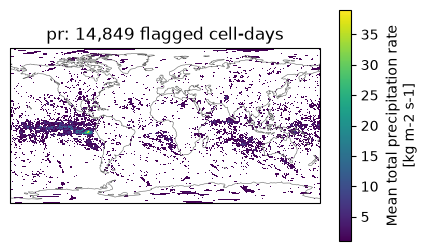

INFO:srm.qa_flags:CESM2-WACCM6_pr_ssp245_008_qdmsd


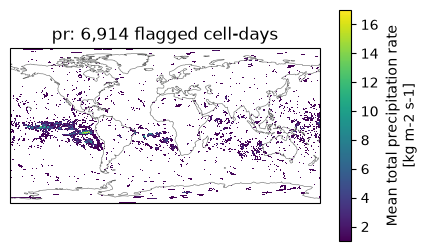

INFO:srm.qa_flags:CESM2-WACCM6_rsds_ssp245_003_qdmsd


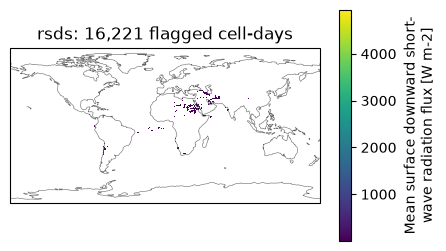

INFO:srm.qa_flags:CESM2-WACCM6_rsds_ssp245_008_qdmsd


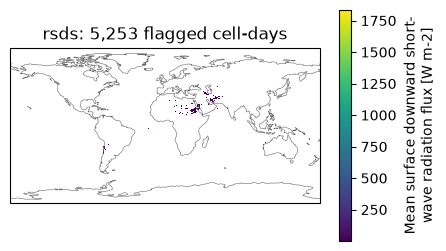

INFO:srm.qa_flags:CESM2-WACCM6_tasmax_ssp245_008_qdmsd


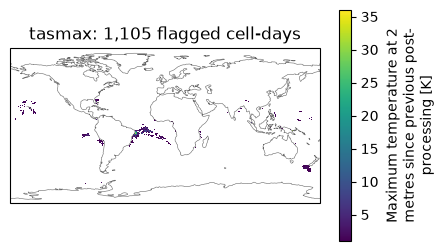

INFO:srm.qa_flags:CESM2-WACCM6_tas_ssp245_003_qdmsd


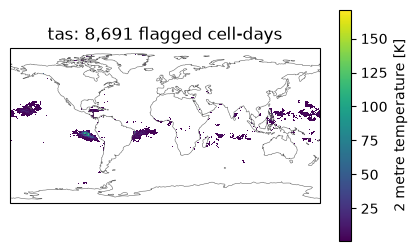

INFO:srm.qa_flags:CESM2-WACCM6_tas_ssp245_008_qdmsd


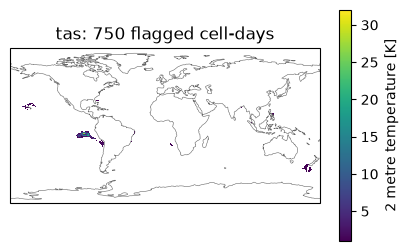

INFO:srm.qa_flags:CESM2-WACCM6_tasmin_ssp245_008_qdmsd


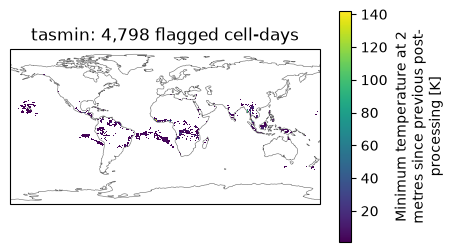

INFO:srm.qa_flags:CESM2-WACCM6_rsds_g6_1p5k_end_002_qdmsd


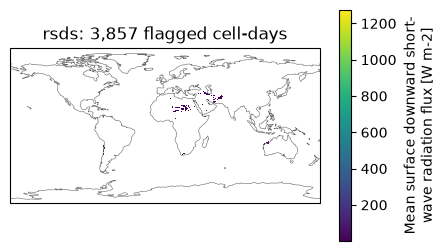

INFO:srm.qa_flags:CESM2-WACCM6_tasmax_g6_1p5k_end_002_qdmsd


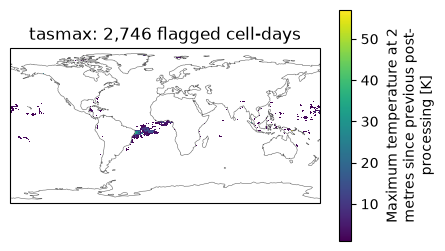

INFO:srm.qa_flags:CESM2-WACCM6_pr_g6_1p5k_end_002_qdmsd


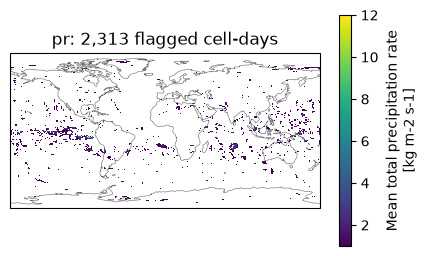

INFO:srm.qa_flags:CESM2-WACCM6_tas_g6_1p5k_end_002_qdmsd


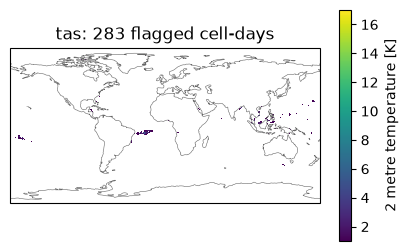

INFO:srm.qa_flags:CESM2-WACCM6_tasmin_g6_1p5k_end_002_qdmsd


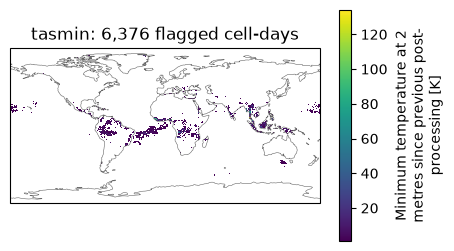

INFO:srm.qa_flags:  flag loop 3/5 completed in 402.6s
INFO:srm.qa_flags:Running flag loop 4/5: rsds max exceedance flag...
INFO:srm.qa_flags:62 tags to process
INFO:srm.qa_flags:CESM2-WACCM6_rsds_g6_1p5k_002_bcsd


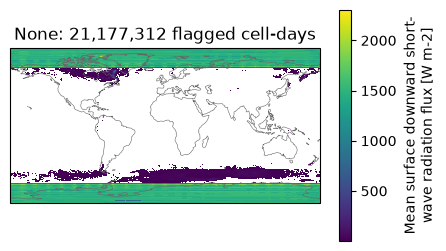

INFO:srm.qa_flags:CESM2-WACCM6_rsds_g6_1p5k_003_bcsd


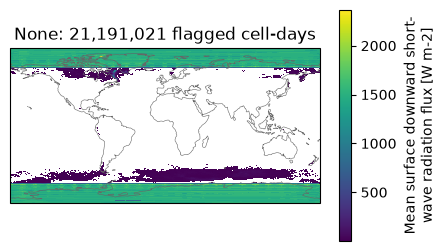

INFO:srm.qa_flags:CESM2-WACCM6_rsds_historical_r2i1p1f1_bcsd


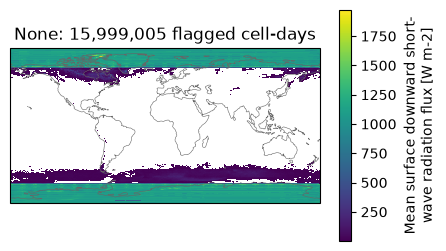

INFO:srm.qa_flags:CESM2-WACCM6_rsds_historical_r3i1p1f1_bcsd


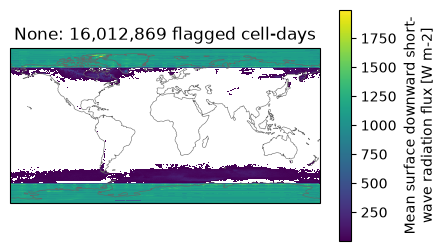

INFO:srm.qa_flags:CESM2-WACCM6_rsds_g6_1p5k_end_002_bcsd


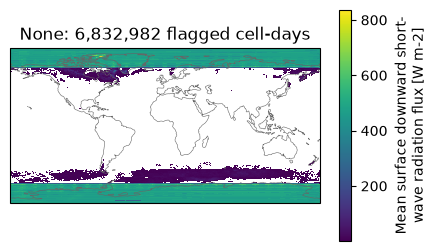

INFO:srm.qa_flags:CESM2-WACCM6_rsds_ssp245_003_bcsd


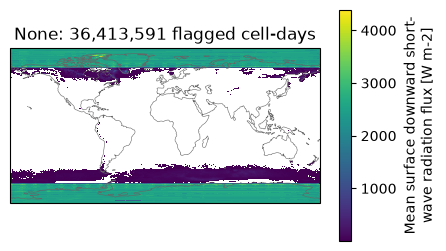

INFO:srm.qa_flags:CESM2-WACCM6_rsds_ssp245_008_bcsd


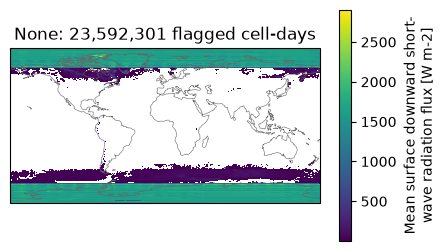

INFO:srm.qa_flags:CESM2-WACCM6_rsds_g6_1p5k_002_qdmsd


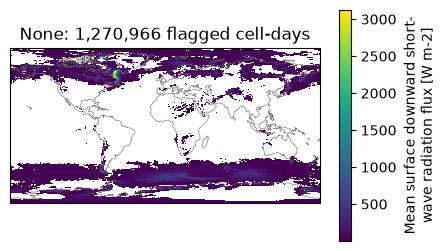

INFO:srm.qa_flags:CESM2-WACCM6_rsds_g6_1p5k_003_qdmsd


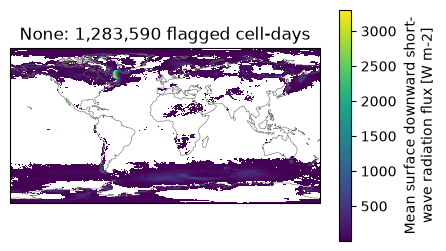

INFO:srm.qa_flags:CESM2-WACCM6_rsds_historical_r2i1p1f1_qdmsd


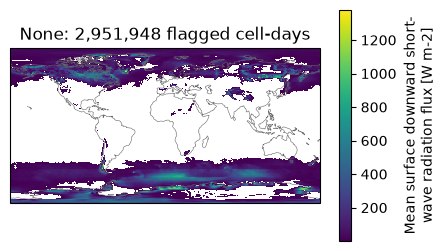

INFO:srm.qa_flags:CESM2-WACCM6_rsds_historical_r3i1p1f1_qdmsd


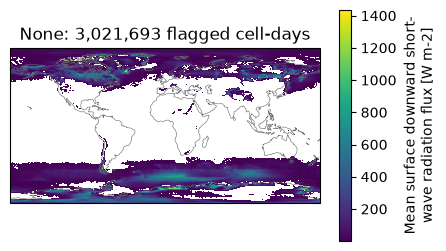

INFO:srm.qa_flags:CESM2-WACCM6_rsds_ssp245_003_qdmsd


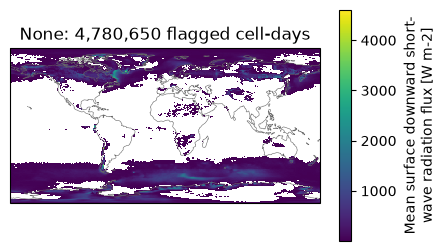

INFO:srm.qa_flags:CESM2-WACCM6_rsds_ssp245_008_qdmsd


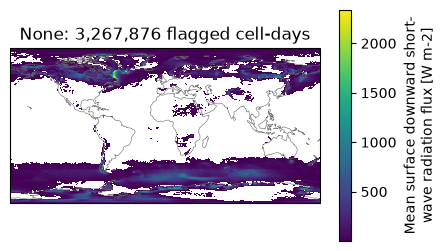

INFO:srm.qa_flags:CESM2-WACCM6_rsds_g6_1p5k_end_002_qdmsd


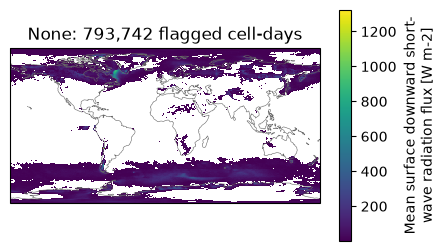

INFO:srm.qa_flags:  flag loop 4/5 completed in 117.8s
INFO:srm.qa_flags:Running flag loop 5/5: trend distortion flag...
INFO:srm.qa_flags:scenario comparison: g6_1p5k_ssp245
INFO:srm.qa_flags:variable: tas


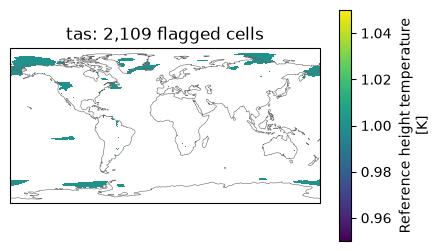

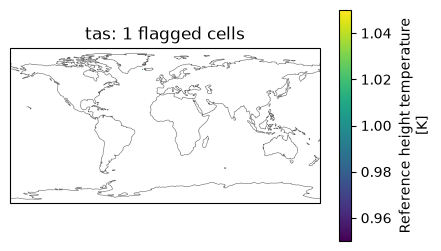

INFO:srm.qa_flags:CESM2-WACCM6_tas_ssp245_003_bcsd
INFO:srm.qa_flags:CESM2-WACCM6_tas_ssp245_008_bcsd
INFO:srm.qa_flags:CESM2-WACCM6_tas_g6_1p5k_002_bcsd
INFO:srm.qa_flags:CESM2-WACCM6_tas_g6_1p5k_003_bcsd
INFO:srm.qa_flags:variable: tas


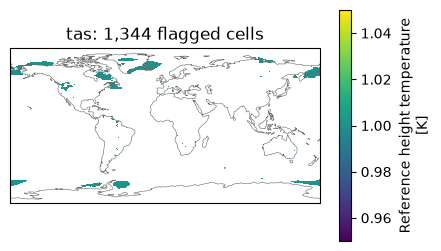

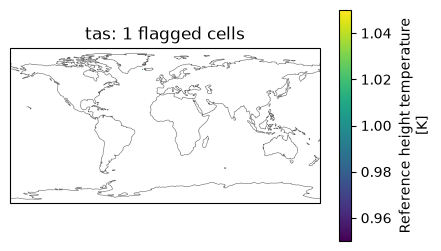

INFO:srm.qa_flags:CESM2-WACCM6_tas_ssp245_003_qdmsd
INFO:srm.qa_flags:CESM2-WACCM6_tas_ssp245_008_qdmsd
INFO:srm.qa_flags:CESM2-WACCM6_tas_g6_1p5k_002_qdmsd
INFO:srm.qa_flags:CESM2-WACCM6_tas_g6_1p5k_003_qdmsd
INFO:srm.qa_flags:variable: tasmax


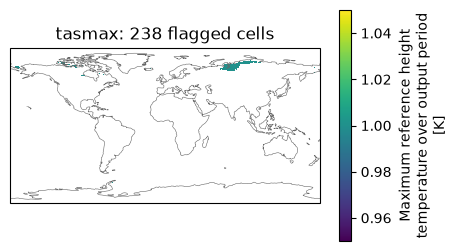

INFO:srm.qa_flags:No flags found.
INFO:srm.qa_flags:CESM2-WACCM6_tasmax_ssp245_008_bcsd
INFO:srm.qa_flags:CESM2-WACCM6_tasmax_g6_1p5k_002_bcsd
INFO:srm.qa_flags:CESM2-WACCM6_tasmax_g6_1p5k_003_bcsd
INFO:srm.qa_flags:variable: tasmax


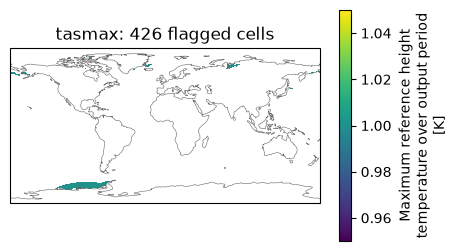

INFO:srm.qa_flags:No flags found.
INFO:srm.qa_flags:CESM2-WACCM6_tasmax_ssp245_008_qdmsd
INFO:srm.qa_flags:CESM2-WACCM6_tasmax_g6_1p5k_002_qdmsd
INFO:srm.qa_flags:CESM2-WACCM6_tasmax_g6_1p5k_003_qdmsd
INFO:srm.qa_flags:variable: tasmin


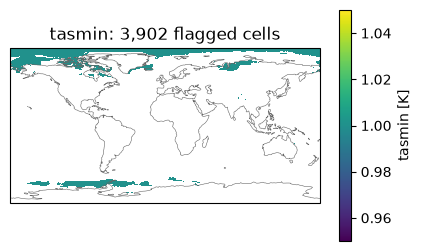

INFO:srm.qa_flags:No flags found.
INFO:srm.qa_flags:CESM2-WACCM6_tasmin_ssp245_008_bcsd
INFO:srm.qa_flags:CESM2-WACCM6_tasmin_g6_1p5k_002_bcsd
INFO:srm.qa_flags:CESM2-WACCM6_tasmin_g6_1p5k_003_bcsd
INFO:srm.qa_flags:variable: tasmin


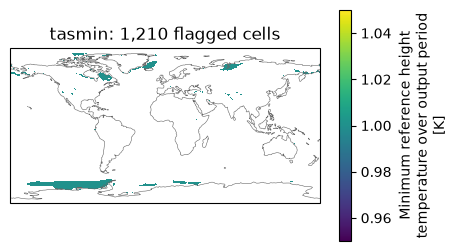

INFO:srm.qa_flags:No flags found.
INFO:srm.qa_flags:CESM2-WACCM6_tasmin_ssp245_008_qdmsd
INFO:srm.qa_flags:CESM2-WACCM6_tasmin_g6_1p5k_002_qdmsd
INFO:srm.qa_flags:CESM2-WACCM6_tasmin_g6_1p5k_003_qdmsd
INFO:srm.qa_flags:variable: pr


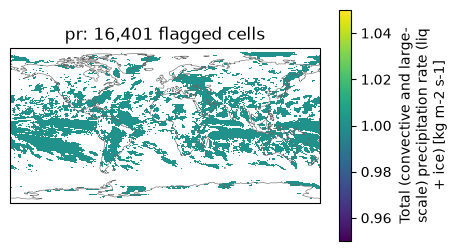

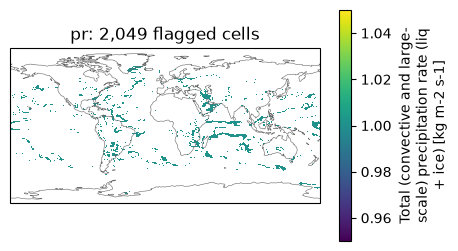

INFO:srm.qa_flags:CESM2-WACCM6_pr_ssp245_008_bcsd
INFO:srm.qa_flags:CESM2-WACCM6_pr_ssp245_003_bcsd
INFO:srm.qa_flags:CESM2-WACCM6_pr_g6_1p5k_002_bcsd
INFO:srm.qa_flags:CESM2-WACCM6_pr_g6_1p5k_003_bcsd
INFO:srm.qa_flags:variable: pr


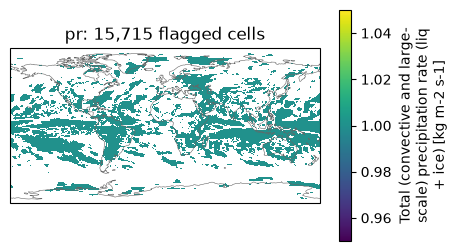

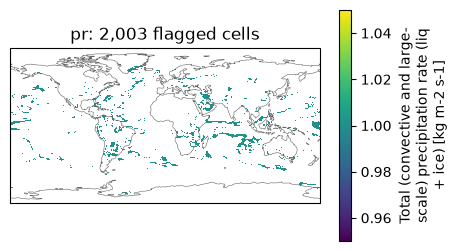

INFO:srm.qa_flags:CESM2-WACCM6_pr_ssp245_003_qdmsd
INFO:srm.qa_flags:CESM2-WACCM6_pr_ssp245_008_qdmsd
INFO:srm.qa_flags:CESM2-WACCM6_pr_g6_1p5k_002_qdmsd
INFO:srm.qa_flags:CESM2-WACCM6_pr_g6_1p5k_003_qdmsd
INFO:srm.qa_flags:variable: rsds


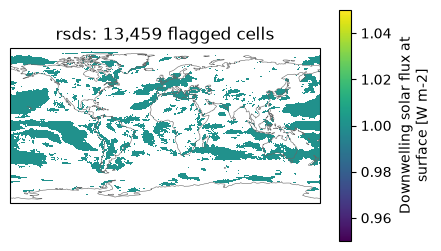

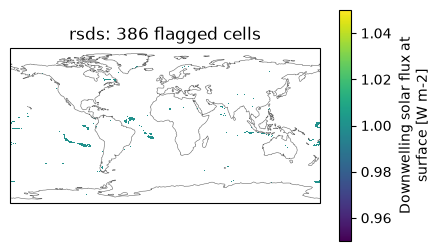

INFO:srm.qa_flags:CESM2-WACCM6_rsds_ssp245_003_bcsd
INFO:srm.qa_flags:CESM2-WACCM6_rsds_ssp245_008_bcsd
INFO:srm.qa_flags:CESM2-WACCM6_rsds_g6_1p5k_002_bcsd
INFO:srm.qa_flags:CESM2-WACCM6_rsds_g6_1p5k_003_bcsd
INFO:srm.qa_flags:variable: rsds


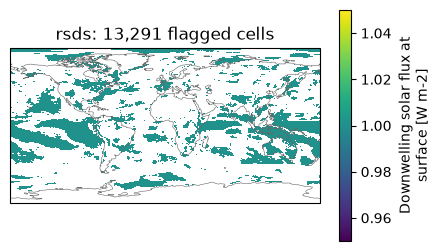

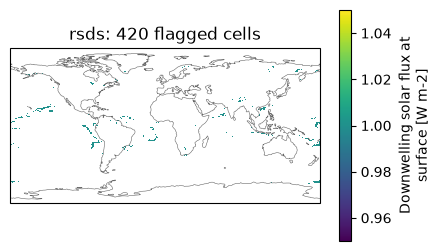

INFO:srm.qa_flags:CESM2-WACCM6_rsds_ssp245_003_qdmsd
INFO:srm.qa_flags:CESM2-WACCM6_rsds_ssp245_008_qdmsd
INFO:srm.qa_flags:CESM2-WACCM6_rsds_g6_1p5k_002_qdmsd
INFO:srm.qa_flags:CESM2-WACCM6_rsds_g6_1p5k_003_qdmsd
INFO:srm.qa_flags:scenario comparison: ssp245_hist
INFO:srm.qa_flags:variable: tas


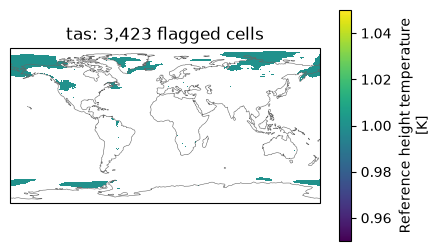

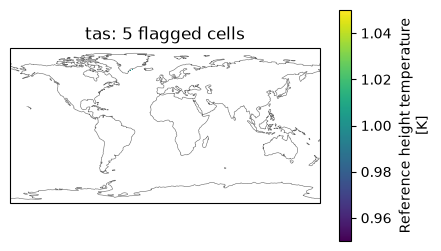

INFO:srm.qa_flags:CESM2-WACCM6_tas_historical_r2i1p1f1_bcsd
INFO:srm.qa_flags:CESM2-WACCM6_tas_historical_r3i1p1f1_bcsd
INFO:srm.qa_flags:CESM2-WACCM6_tas_ssp245_003_bcsd
INFO:srm.qa_flags:CESM2-WACCM6_tas_ssp245_008_bcsd
INFO:srm.qa_flags:variable: tas


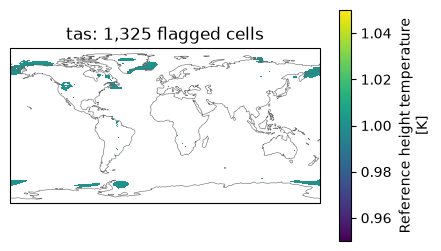

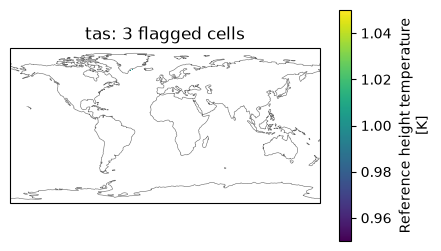

INFO:srm.qa_flags:CESM2-WACCM6_tas_historical_r2i1p1f1_qdmsd
INFO:srm.qa_flags:CESM2-WACCM6_tas_historical_r3i1p1f1_qdmsd
INFO:srm.qa_flags:CESM2-WACCM6_tas_ssp245_003_qdmsd
INFO:srm.qa_flags:CESM2-WACCM6_tas_ssp245_008_qdmsd
INFO:srm.qa_flags:variable: tasmax


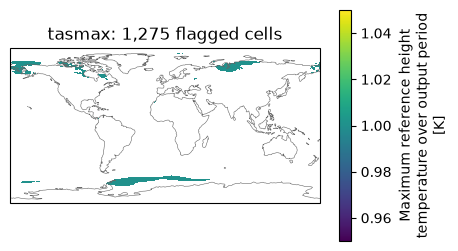

INFO:srm.qa_flags:No flags found.
INFO:srm.qa_flags:CESM2-WACCM6_tasmax_historical_001_bcsd
INFO:srm.qa_flags:CESM2-WACCM6_tasmax_ssp245_008_bcsd
INFO:srm.qa_flags:variable: tasmax


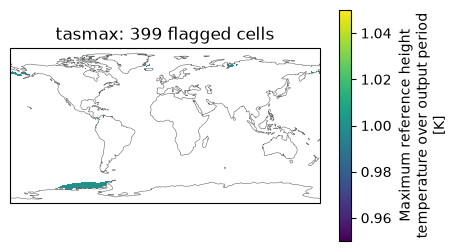

INFO:srm.qa_flags:No flags found.
INFO:srm.qa_flags:CESM2-WACCM6_tasmax_historical_001_qdmsd
INFO:srm.qa_flags:CESM2-WACCM6_tasmax_ssp245_008_qdmsd
INFO:srm.qa_flags:variable: tasmin


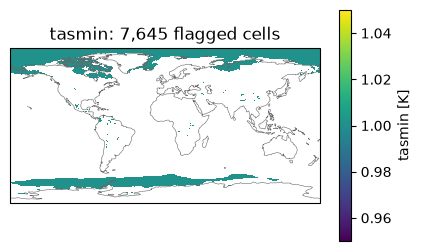

INFO:srm.qa_flags:No flags found.
INFO:srm.qa_flags:CESM2-WACCM6_tasmin_historical_001_bcsd
INFO:srm.qa_flags:CESM2-WACCM6_tasmin_ssp245_008_bcsd
INFO:srm.qa_flags:variable: tasmin


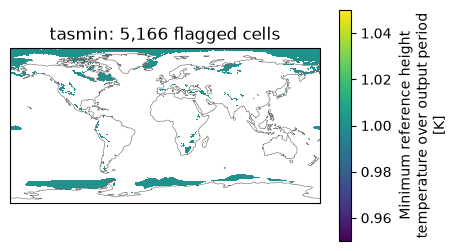

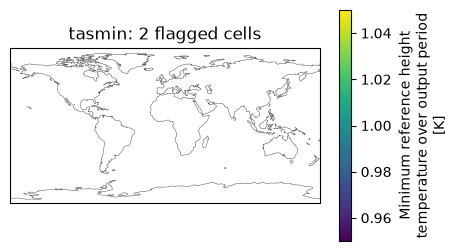

INFO:srm.qa_flags:CESM2-WACCM6_tasmin_historical_001_qdmsd
INFO:srm.qa_flags:CESM2-WACCM6_tasmin_ssp245_008_qdmsd
INFO:srm.qa_flags:variable: pr


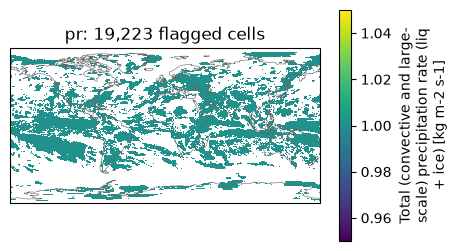

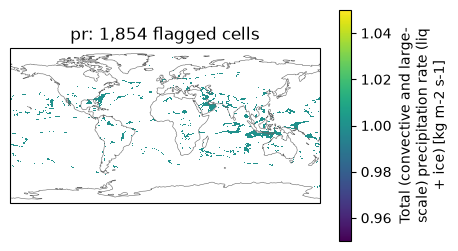

INFO:srm.qa_flags:CESM2-WACCM6_pr_historical_r2i1p1f1_bcsd
INFO:srm.qa_flags:CESM2-WACCM6_pr_historical_r3i1p1f1_bcsd
INFO:srm.qa_flags:CESM2-WACCM6_pr_ssp245_008_bcsd
INFO:srm.qa_flags:CESM2-WACCM6_pr_ssp245_003_bcsd
INFO:srm.qa_flags:variable: pr


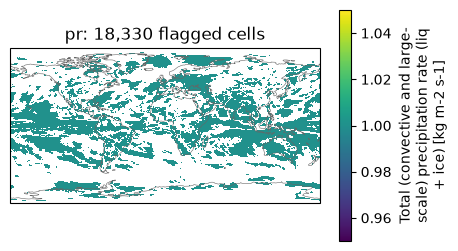

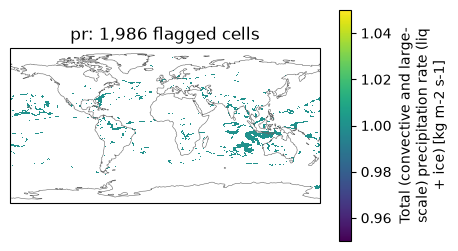

INFO:srm.qa_flags:CESM2-WACCM6_pr_historical_r2i1p1f1_qdmsd
INFO:srm.qa_flags:CESM2-WACCM6_pr_historical_r3i1p1f1_qdmsd
INFO:srm.qa_flags:CESM2-WACCM6_pr_ssp245_003_qdmsd
INFO:srm.qa_flags:CESM2-WACCM6_pr_ssp245_008_qdmsd
INFO:srm.qa_flags:variable: rsds


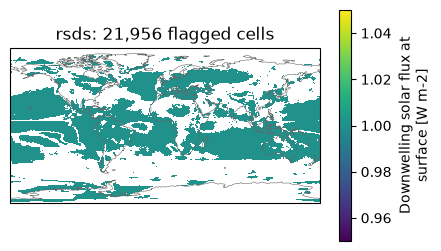

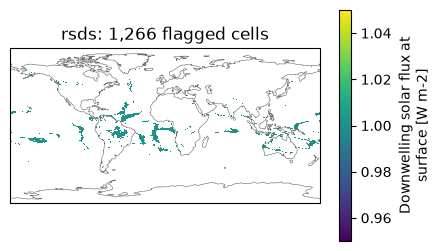

INFO:srm.qa_flags:CESM2-WACCM6_rsds_historical_r2i1p1f1_bcsd
INFO:srm.qa_flags:CESM2-WACCM6_rsds_historical_r3i1p1f1_bcsd
INFO:srm.qa_flags:CESM2-WACCM6_rsds_ssp245_003_bcsd
INFO:srm.qa_flags:CESM2-WACCM6_rsds_ssp245_008_bcsd
INFO:srm.qa_flags:variable: rsds


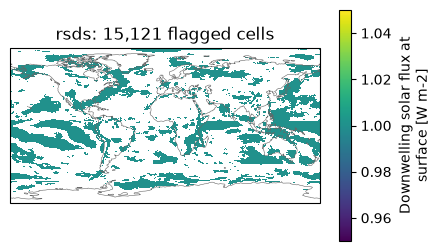

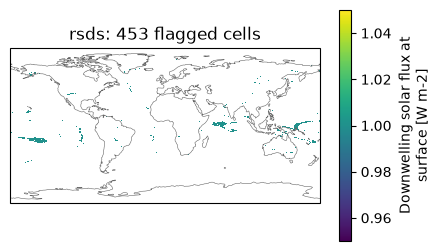

INFO:srm.qa_flags:CESM2-WACCM6_rsds_historical_r2i1p1f1_qdmsd
INFO:srm.qa_flags:CESM2-WACCM6_rsds_historical_r3i1p1f1_qdmsd
INFO:srm.qa_flags:CESM2-WACCM6_rsds_ssp245_003_qdmsd
INFO:srm.qa_flags:CESM2-WACCM6_rsds_ssp245_008_qdmsd
INFO:srm.qa_flags:scenario comparison: g6_1p5k_hist
INFO:srm.qa_flags:variable: tas


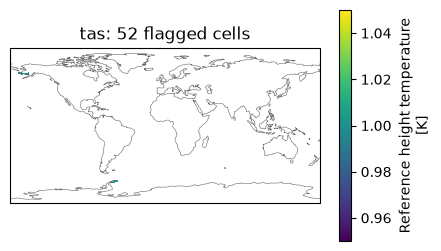

INFO:srm.qa_flags:No flags found.
INFO:srm.qa_flags:CESM2-WACCM6_tas_historical_r2i1p1f1_bcsd
INFO:srm.qa_flags:CESM2-WACCM6_tas_historical_r3i1p1f1_bcsd
INFO:srm.qa_flags:CESM2-WACCM6_tas_g6_1p5k_002_bcsd
INFO:srm.qa_flags:CESM2-WACCM6_tas_g6_1p5k_003_bcsd
INFO:srm.qa_flags:variable: tas
INFO:srm.qa_flags:No flags found.
INFO:srm.qa_flags:No flags found.
INFO:srm.qa_flags:CESM2-WACCM6_tas_historical_r2i1p1f1_qdmsd
INFO:srm.qa_flags:CESM2-WACCM6_tas_historical_r3i1p1f1_qdmsd
INFO:srm.qa_flags:CESM2-WACCM6_tas_g6_1p5k_002_qdmsd
INFO:srm.qa_flags:CESM2-WACCM6_tas_g6_1p5k_003_qdmsd
INFO:srm.qa_flags:variable: tasmax


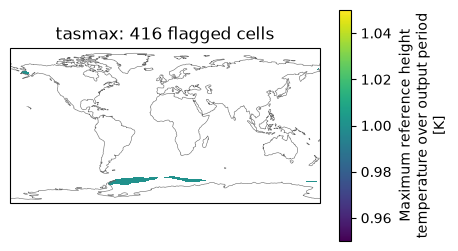

INFO:srm.qa_flags:No flags found.
INFO:srm.qa_flags:CESM2-WACCM6_tasmax_historical_001_bcsd
INFO:srm.qa_flags:CESM2-WACCM6_tasmax_g6_1p5k_002_bcsd
INFO:srm.qa_flags:CESM2-WACCM6_tasmax_g6_1p5k_003_bcsd
INFO:srm.qa_flags:variable: tasmax
INFO:srm.qa_flags:No flags found.
INFO:srm.qa_flags:No flags found.
INFO:srm.qa_flags:CESM2-WACCM6_tasmax_historical_001_qdmsd
INFO:srm.qa_flags:CESM2-WACCM6_tasmax_g6_1p5k_002_qdmsd
INFO:srm.qa_flags:CESM2-WACCM6_tasmax_g6_1p5k_003_qdmsd
INFO:srm.qa_flags:variable: tasmin


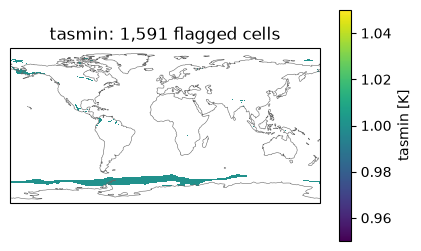

INFO:srm.qa_flags:No flags found.
INFO:srm.qa_flags:CESM2-WACCM6_tasmin_historical_001_bcsd
INFO:srm.qa_flags:CESM2-WACCM6_tasmin_g6_1p5k_002_bcsd
INFO:srm.qa_flags:CESM2-WACCM6_tasmin_g6_1p5k_003_bcsd
INFO:srm.qa_flags:variable: tasmin


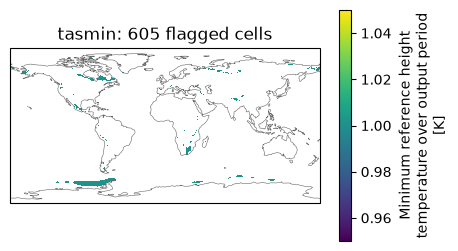

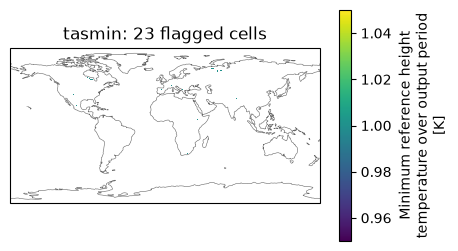

INFO:srm.qa_flags:CESM2-WACCM6_tasmin_historical_001_qdmsd
INFO:srm.qa_flags:CESM2-WACCM6_tasmin_g6_1p5k_002_qdmsd
INFO:srm.qa_flags:CESM2-WACCM6_tasmin_g6_1p5k_003_qdmsd
INFO:srm.qa_flags:variable: pr


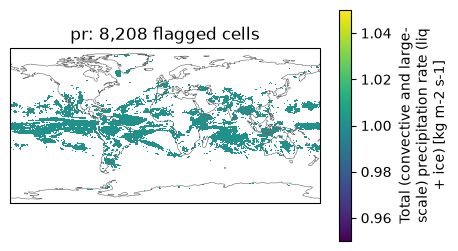

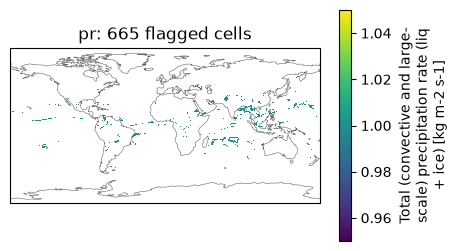

INFO:srm.qa_flags:CESM2-WACCM6_pr_historical_r2i1p1f1_bcsd
INFO:srm.qa_flags:CESM2-WACCM6_pr_historical_r3i1p1f1_bcsd
INFO:srm.qa_flags:CESM2-WACCM6_pr_g6_1p5k_002_bcsd
INFO:srm.qa_flags:CESM2-WACCM6_pr_g6_1p5k_003_bcsd
INFO:srm.qa_flags:variable: pr


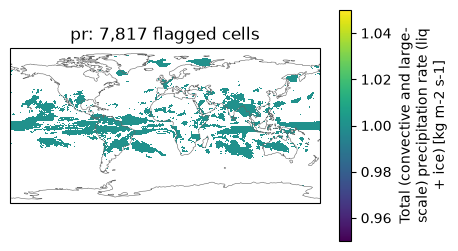

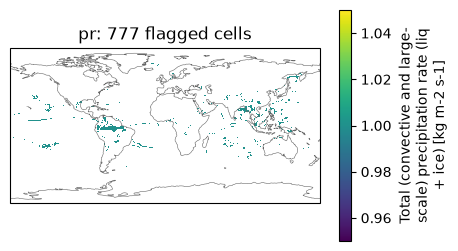

INFO:srm.qa_flags:CESM2-WACCM6_pr_historical_r2i1p1f1_qdmsd
INFO:srm.qa_flags:CESM2-WACCM6_pr_historical_r3i1p1f1_qdmsd
INFO:srm.qa_flags:CESM2-WACCM6_pr_g6_1p5k_002_qdmsd
INFO:srm.qa_flags:CESM2-WACCM6_pr_g6_1p5k_003_qdmsd
INFO:srm.qa_flags:variable: rsds


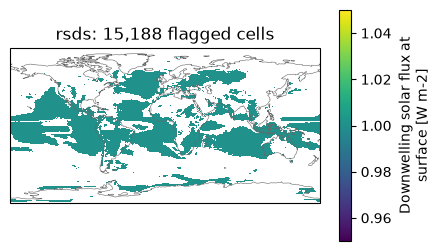

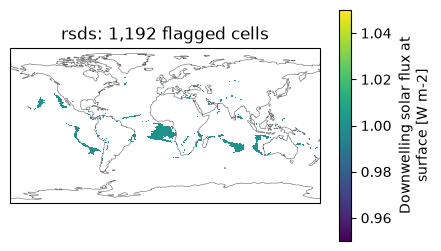

INFO:srm.qa_flags:CESM2-WACCM6_rsds_historical_r2i1p1f1_bcsd
INFO:srm.qa_flags:CESM2-WACCM6_rsds_historical_r3i1p1f1_bcsd
INFO:srm.qa_flags:CESM2-WACCM6_rsds_g6_1p5k_002_bcsd
INFO:srm.qa_flags:CESM2-WACCM6_rsds_g6_1p5k_003_bcsd
INFO:srm.qa_flags:variable: rsds


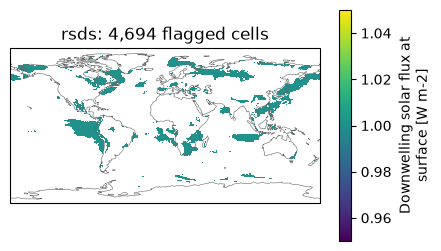

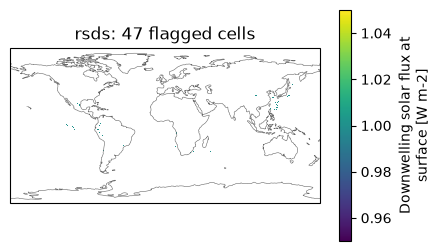

INFO:srm.qa_flags:CESM2-WACCM6_rsds_historical_r2i1p1f1_qdmsd
INFO:srm.qa_flags:CESM2-WACCM6_rsds_historical_r3i1p1f1_qdmsd
INFO:srm.qa_flags:CESM2-WACCM6_rsds_g6_1p5k_002_qdmsd
INFO:srm.qa_flags:CESM2-WACCM6_rsds_g6_1p5k_003_qdmsd
INFO:srm.qa_flags:scenario comparison: g6_1p5k_end_g6_1p5k
INFO:srm.qa_flags:variable: tas


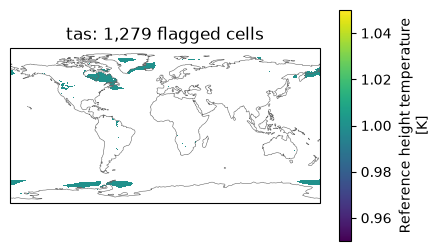

INFO:srm.qa_flags:No flags found.
INFO:srm.qa_flags:CESM2-WACCM6_tas_g6_1p5k_002_bcsd
INFO:srm.qa_flags:CESM2-WACCM6_tas_g6_1p5k_003_bcsd
INFO:srm.qa_flags:CESM2-WACCM6_tas_g6_1p5k_end_002_bcsd
INFO:srm.qa_flags:variable: tas


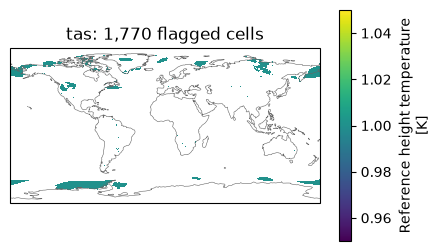

INFO:srm.qa_flags:No flags found.
INFO:srm.qa_flags:CESM2-WACCM6_tas_g6_1p5k_002_qdmsd
INFO:srm.qa_flags:CESM2-WACCM6_tas_g6_1p5k_003_qdmsd
INFO:srm.qa_flags:CESM2-WACCM6_tas_g6_1p5k_end_002_qdmsd
INFO:srm.qa_flags:variable: tasmax


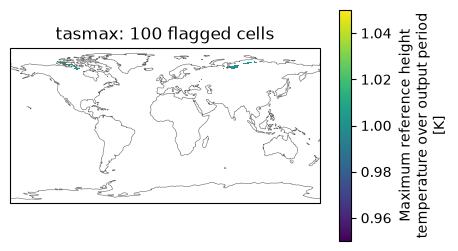

INFO:srm.qa_flags:No flags found.
INFO:srm.qa_flags:CESM2-WACCM6_tasmax_g6_1p5k_002_bcsd
INFO:srm.qa_flags:CESM2-WACCM6_tasmax_g6_1p5k_003_bcsd
INFO:srm.qa_flags:CESM2-WACCM6_tasmax_g6_1p5k_end_002_bcsd
INFO:srm.qa_flags:variable: tasmax


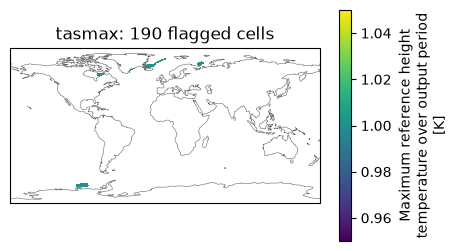

INFO:srm.qa_flags:No flags found.
INFO:srm.qa_flags:CESM2-WACCM6_tasmax_g6_1p5k_002_qdmsd
INFO:srm.qa_flags:CESM2-WACCM6_tasmax_g6_1p5k_003_qdmsd
INFO:srm.qa_flags:CESM2-WACCM6_tasmax_g6_1p5k_end_002_qdmsd
INFO:srm.qa_flags:variable: tasmin


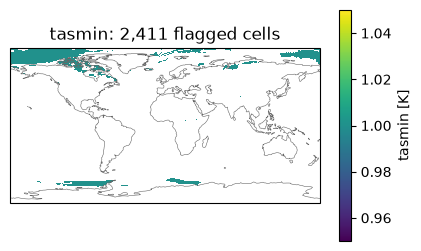

INFO:srm.qa_flags:No flags found.
INFO:srm.qa_flags:CESM2-WACCM6_tasmin_g6_1p5k_002_bcsd
INFO:srm.qa_flags:CESM2-WACCM6_tasmin_g6_1p5k_003_bcsd
INFO:srm.qa_flags:CESM2-WACCM6_tasmin_g6_1p5k_end_002_bcsd
INFO:srm.qa_flags:variable: tasmin


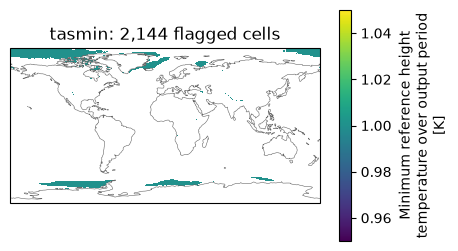

INFO:srm.qa_flags:No flags found.
INFO:srm.qa_flags:CESM2-WACCM6_tasmin_g6_1p5k_002_qdmsd
INFO:srm.qa_flags:CESM2-WACCM6_tasmin_g6_1p5k_003_qdmsd
INFO:srm.qa_flags:CESM2-WACCM6_tasmin_g6_1p5k_end_002_qdmsd
INFO:srm.qa_flags:variable: pr


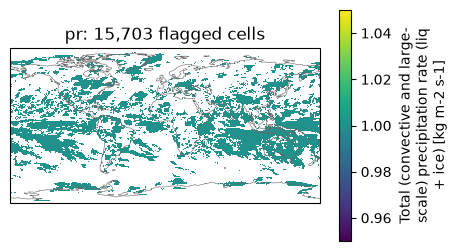

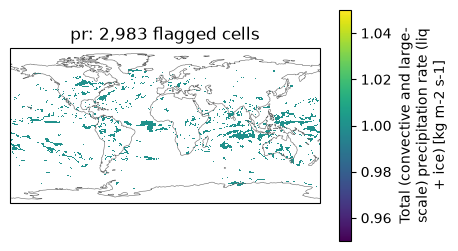

INFO:srm.qa_flags:CESM2-WACCM6_pr_g6_1p5k_002_bcsd
INFO:srm.qa_flags:CESM2-WACCM6_pr_g6_1p5k_003_bcsd
INFO:srm.qa_flags:CESM2-WACCM6_pr_g6_1p5k_end_002_bcsd
INFO:srm.qa_flags:variable: pr


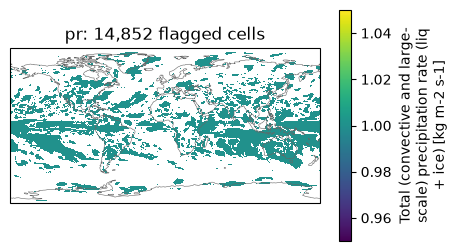

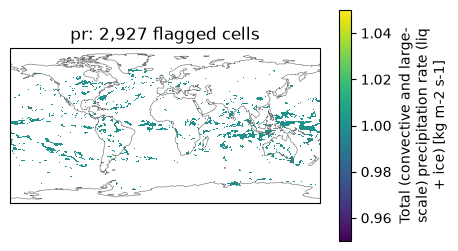

INFO:srm.qa_flags:CESM2-WACCM6_pr_g6_1p5k_002_qdmsd
INFO:srm.qa_flags:CESM2-WACCM6_pr_g6_1p5k_003_qdmsd
INFO:srm.qa_flags:CESM2-WACCM6_pr_g6_1p5k_end_002_qdmsd
INFO:srm.qa_flags:variable: rsds


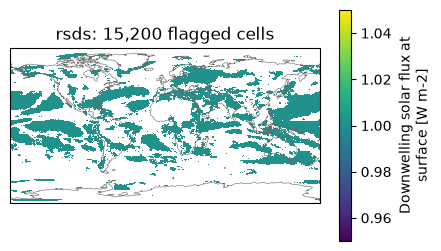

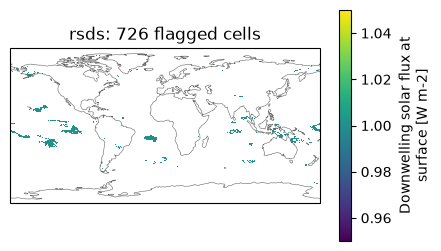

INFO:srm.qa_flags:CESM2-WACCM6_rsds_g6_1p5k_002_bcsd
INFO:srm.qa_flags:CESM2-WACCM6_rsds_g6_1p5k_003_bcsd
INFO:srm.qa_flags:CESM2-WACCM6_rsds_g6_1p5k_end_002_bcsd
INFO:srm.qa_flags:variable: rsds


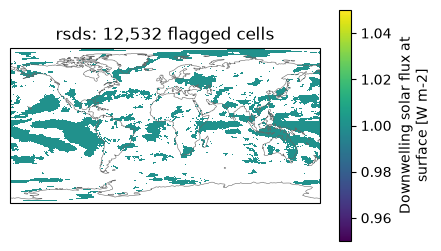

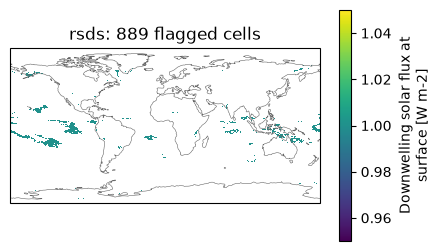

INFO:srm.qa_flags:CESM2-WACCM6_rsds_g6_1p5k_002_qdmsd
INFO:srm.qa_flags:CESM2-WACCM6_rsds_g6_1p5k_003_qdmsd
INFO:srm.qa_flags:CESM2-WACCM6_rsds_g6_1p5k_end_002_qdmsd
INFO:srm.qa_flags:  flag loop 5/5 completed in 1711.2s
INFO:srm.qa_flags:calculate_all_flags total time: 2757.6s
INFO:srm.qa_flags:  flags on coarse debiased data for CESM2-WACCM6 completed in 2757.6s
INFO:srm.qa_flags:Running flag loop 1/5: global exceedance flag...
INFO:srm.qa_flags:30 tags to process
INFO:srm.qa_flags:UKESM1-1-LL_pr_g6_1p5k_r2i1p1f2_bcsd
INFO:srm.qa_flags:No flags found.
INFO:srm.qa_flags:UKESM1-1-LL_rsds_g6_1p5k_r2i1p1f2_bcsd
INFO:srm.qa_flags:No flags found.
INFO:srm.qa_flags:UKESM1-1-LL_tas_g6_1p5k_r2i1p1f2_bcsd
INFO:srm.qa_flags:No flags found.
INFO:srm.qa_flags:UKESM1-1-LL_tasmax_g6_1p5k_r2i1p1f2_bcsd
INFO:srm.qa_flags:No flags found.
INFO:srm.qa_flags:UKESM1-1-LL_tasmin_g6_1p5k_r2i1p1f2_bcsd
INFO:srm.qa_flags:No flags found.
INFO:srm.qa_flags:UKESM1-1-LL_rsds_ssp245_r2i1p1f2_bcsd
INFO:srm.qa_flags

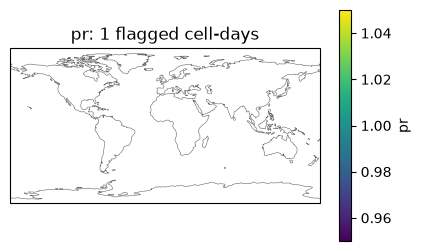

INFO:srm.qa_flags:UKESM1-1-LL_tasmax_g6_1p5k_r2i1p1f2_qdmsd
INFO:srm.qa_flags:No flags found.
INFO:srm.qa_flags:UKESM1-1-LL_tasmin_g6_1p5k_r2i1p1f2_qdmsd
INFO:srm.qa_flags:No flags found.
INFO:srm.qa_flags:UKESM1-1-LL_rsds_g6_1p5k_r2i1p1f2_qdmsd


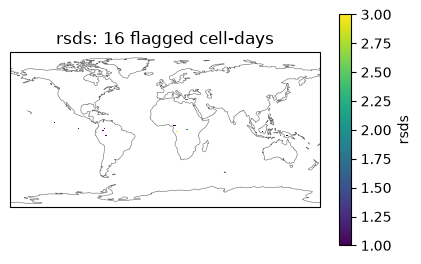

INFO:srm.qa_flags:UKESM1-1-LL_tas_historical_u-by791_qdmsd
INFO:srm.qa_flags:No flags found.
INFO:srm.qa_flags:UKESM1-1-LL_pr_historical_u-by791_qdmsd
INFO:srm.qa_flags:No flags found.
INFO:srm.qa_flags:UKESM1-1-LL_tasmax_historical_u-by791_qdmsd
INFO:srm.qa_flags:No flags found.
INFO:srm.qa_flags:UKESM1-1-LL_rsds_historical_u-by791_qdmsd
INFO:srm.qa_flags:No flags found.
INFO:srm.qa_flags:UKESM1-1-LL_tasmin_historical_u-by791_qdmsd
INFO:srm.qa_flags:No flags found.
INFO:srm.qa_flags:UKESM1-1-LL_tas_ssp245_r2i1p1f2_qdmsd
INFO:srm.qa_flags:No flags found.
INFO:srm.qa_flags:UKESM1-1-LL_tasmin_ssp245_r2i1p1f2_qdmsd
INFO:srm.qa_flags:No flags found.
INFO:srm.qa_flags:UKESM1-1-LL_pr_ssp245_r2i1p1f2_qdmsd


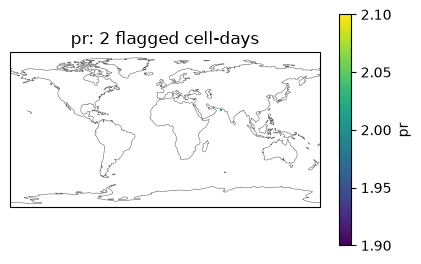

INFO:srm.qa_flags:UKESM1-1-LL_rsds_ssp245_r2i1p1f2_qdmsd


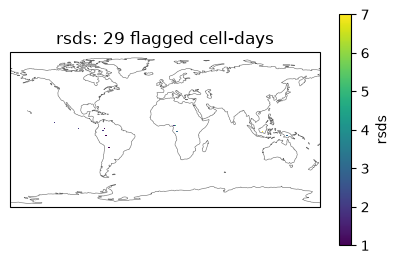

INFO:srm.qa_flags:UKESM1-1-LL_tasmax_ssp245_r2i1p1f2_qdmsd
INFO:srm.qa_flags:No flags found.
INFO:srm.qa_flags:  flag loop 1/5 completed in 142.1s
INFO:srm.qa_flags:Running flag loop 2/5: temperature inconsistency flag...
INFO:srm.qa_flags:30 tags to process
INFO:srm.qa_flags:UKESM1-1-LL_tas_g6_1p5k_r2i1p1f2_bcsd


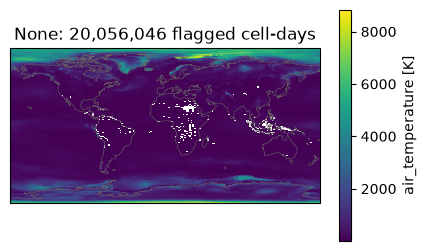

INFO:srm.qa_flags:UKESM1-1-LL_tas_ssp245_r2i1p1f2_bcsd


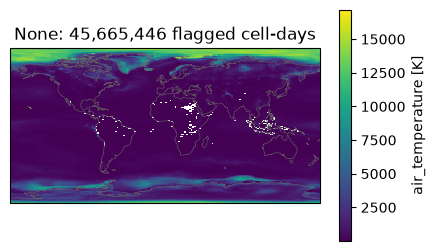

INFO:srm.qa_flags:UKESM1-1-LL_tas_historical_u-by791_bcsd


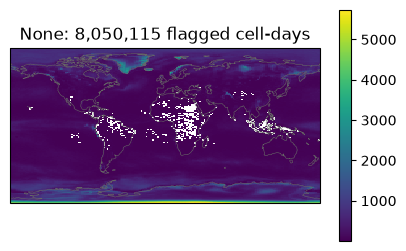

INFO:srm.qa_flags:UKESM1-1-LL_tas_g6_1p5k_r2i1p1f2_qdmsd


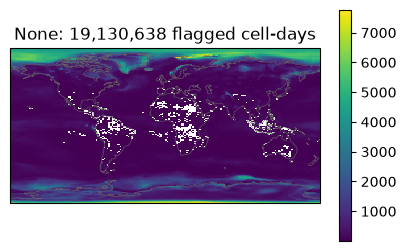

INFO:srm.qa_flags:UKESM1-1-LL_tas_historical_u-by791_qdmsd


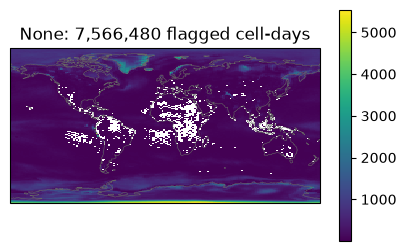

INFO:srm.qa_flags:UKESM1-1-LL_tas_ssp245_r2i1p1f2_qdmsd


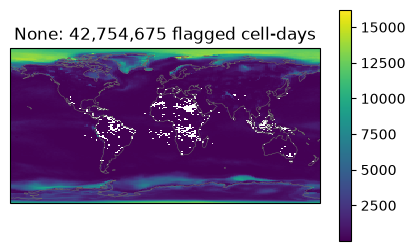

INFO:srm.qa_flags:  flag loop 2/5 completed in 100.4s
INFO:srm.qa_flags:Running flag loop 3/5: annual outlier flag...
INFO:srm.qa_flags:30 tags to process
INFO:srm.qa_flags:UKESM1-1-LL_pr_g6_1p5k_r2i1p1f2_bcsd


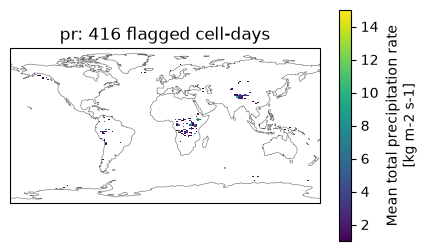

INFO:srm.qa_flags:UKESM1-1-LL_rsds_g6_1p5k_r2i1p1f2_bcsd
INFO:srm.qa_flags:No flags found.
INFO:srm.qa_flags:UKESM1-1-LL_tas_g6_1p5k_r2i1p1f2_bcsd


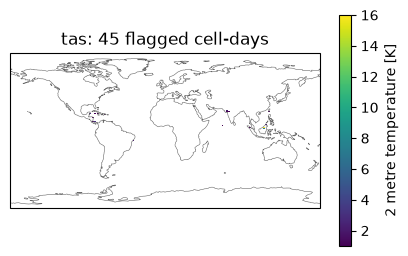

INFO:srm.qa_flags:UKESM1-1-LL_tasmax_g6_1p5k_r2i1p1f2_bcsd


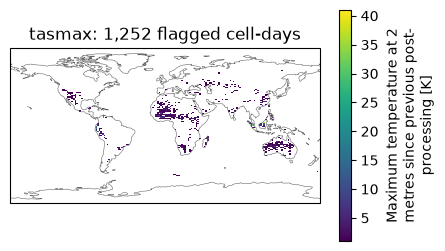

INFO:srm.qa_flags:UKESM1-1-LL_tasmin_g6_1p5k_r2i1p1f2_bcsd


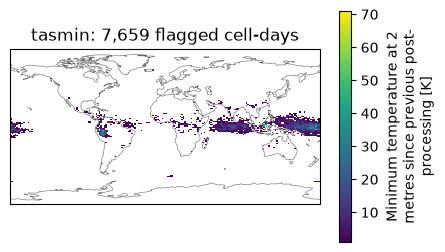

INFO:srm.qa_flags:UKESM1-1-LL_rsds_ssp245_r2i1p1f2_bcsd
INFO:srm.qa_flags:No flags found.
INFO:srm.qa_flags:UKESM1-1-LL_tasmax_ssp245_r2i1p1f2_bcsd


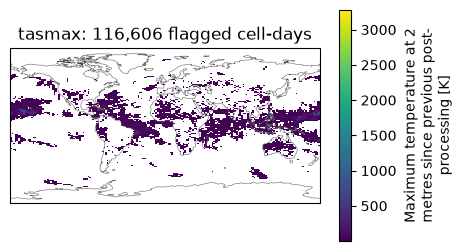

INFO:srm.qa_flags:UKESM1-1-LL_tasmin_ssp245_r2i1p1f2_bcsd


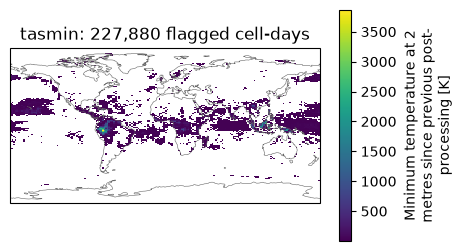

INFO:srm.qa_flags:UKESM1-1-LL_pr_ssp245_r2i1p1f2_bcsd


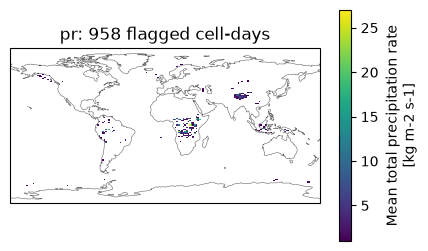

INFO:srm.qa_flags:UKESM1-1-LL_tas_ssp245_r2i1p1f2_bcsd


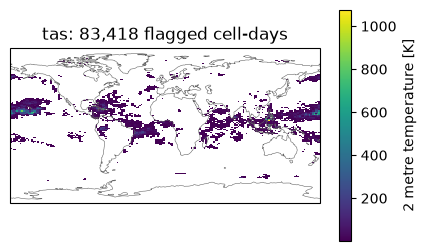

INFO:srm.qa_flags:UKESM1-1-LL_pr_historical_u-by791_bcsd
INFO:srm.qa_flags:No flags found.
INFO:srm.qa_flags:UKESM1-1-LL_tasmax_historical_u-by791_bcsd
INFO:srm.qa_flags:No flags found.
INFO:srm.qa_flags:UKESM1-1-LL_rsds_historical_u-by791_bcsd
INFO:srm.qa_flags:No flags found.
INFO:srm.qa_flags:UKESM1-1-LL_tas_historical_u-by791_bcsd
INFO:srm.qa_flags:No flags found.
INFO:srm.qa_flags:UKESM1-1-LL_tasmin_historical_u-by791_bcsd


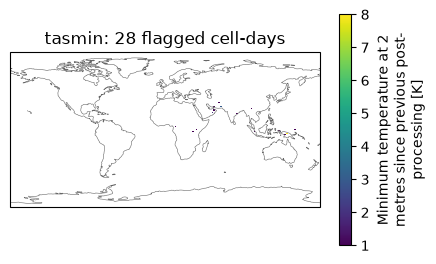

INFO:srm.qa_flags:UKESM1-1-LL_tas_g6_1p5k_r2i1p1f2_qdmsd


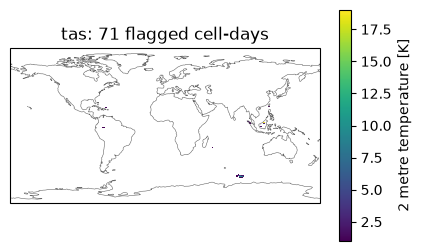

INFO:srm.qa_flags:UKESM1-1-LL_pr_g6_1p5k_r2i1p1f2_qdmsd


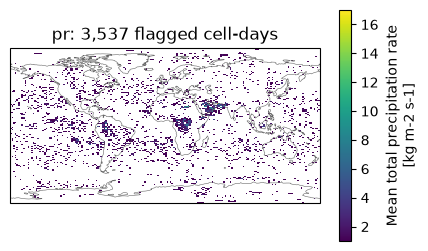

INFO:srm.qa_flags:UKESM1-1-LL_tasmax_g6_1p5k_r2i1p1f2_qdmsd


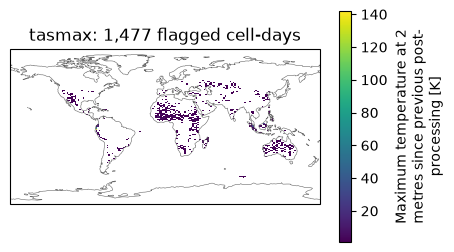

INFO:srm.qa_flags:UKESM1-1-LL_tasmin_g6_1p5k_r2i1p1f2_qdmsd


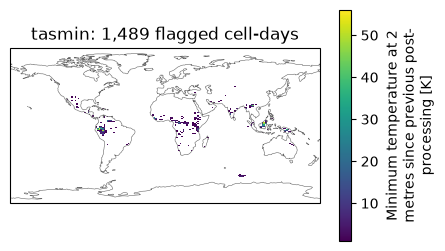

INFO:srm.qa_flags:UKESM1-1-LL_rsds_g6_1p5k_r2i1p1f2_qdmsd


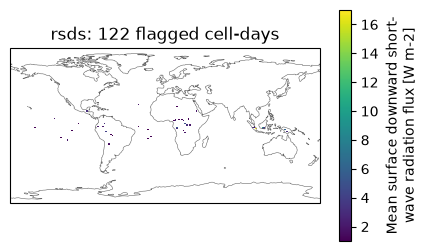

INFO:srm.qa_flags:UKESM1-1-LL_tas_historical_u-by791_qdmsd
INFO:srm.qa_flags:No flags found.
INFO:srm.qa_flags:UKESM1-1-LL_pr_historical_u-by791_qdmsd
INFO:srm.qa_flags:No flags found.
INFO:srm.qa_flags:UKESM1-1-LL_tasmax_historical_u-by791_qdmsd
INFO:srm.qa_flags:No flags found.
INFO:srm.qa_flags:UKESM1-1-LL_rsds_historical_u-by791_qdmsd
INFO:srm.qa_flags:No flags found.
INFO:srm.qa_flags:UKESM1-1-LL_tasmin_historical_u-by791_qdmsd


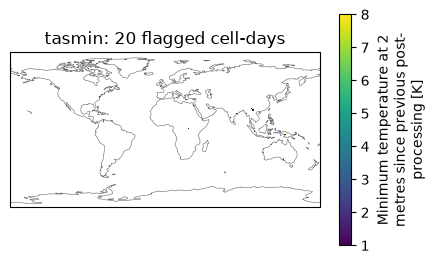

INFO:srm.qa_flags:UKESM1-1-LL_tas_ssp245_r2i1p1f2_qdmsd


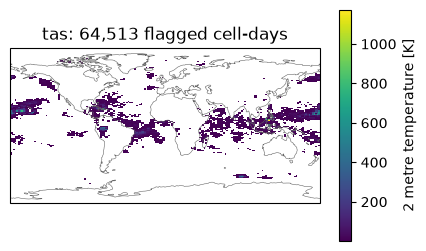

INFO:srm.qa_flags:UKESM1-1-LL_tasmin_ssp245_r2i1p1f2_qdmsd


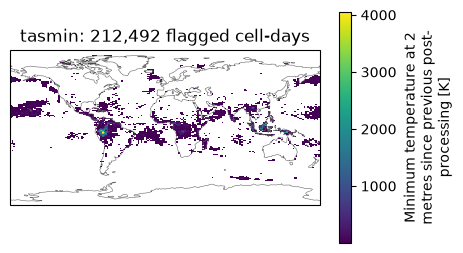

INFO:srm.qa_flags:UKESM1-1-LL_pr_ssp245_r2i1p1f2_qdmsd


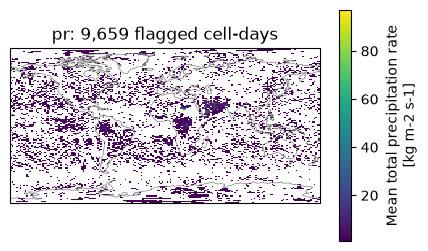

INFO:srm.qa_flags:UKESM1-1-LL_rsds_ssp245_r2i1p1f2_qdmsd


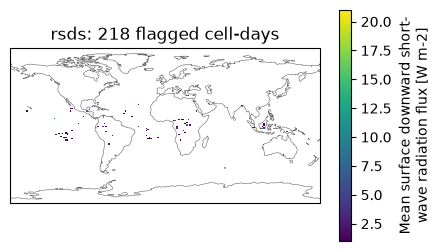

INFO:srm.qa_flags:UKESM1-1-LL_tasmax_ssp245_r2i1p1f2_qdmsd


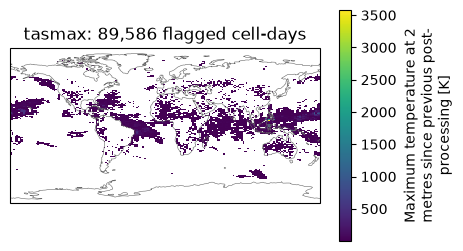

INFO:srm.qa_flags:  flag loop 3/5 completed in 162.1s
INFO:srm.qa_flags:Running flag loop 4/5: rsds max exceedance flag...
INFO:srm.qa_flags:30 tags to process
INFO:srm.qa_flags:UKESM1-1-LL_rsds_g6_1p5k_r2i1p1f2_bcsd


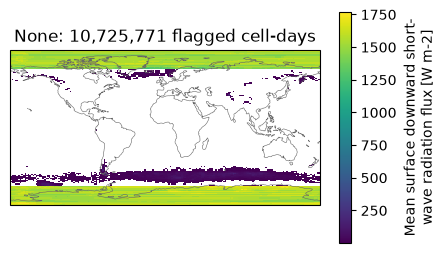

INFO:srm.qa_flags:UKESM1-1-LL_rsds_ssp245_r2i1p1f2_bcsd


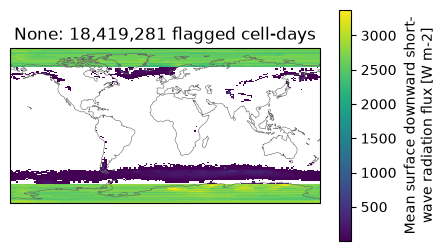

INFO:srm.qa_flags:UKESM1-1-LL_rsds_historical_u-by791_bcsd


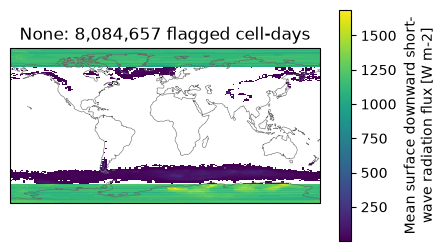

INFO:srm.qa_flags:UKESM1-1-LL_rsds_g6_1p5k_r2i1p1f2_qdmsd


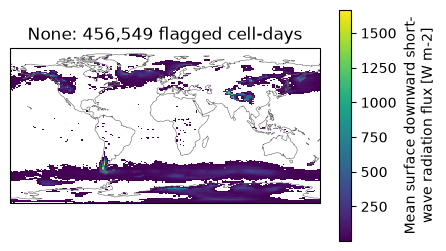

INFO:srm.qa_flags:UKESM1-1-LL_rsds_historical_u-by791_qdmsd


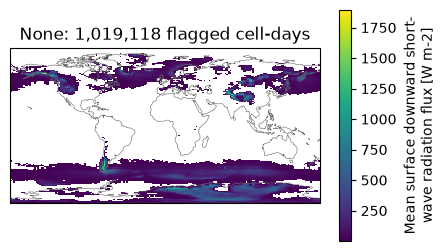

INFO:srm.qa_flags:UKESM1-1-LL_rsds_ssp245_r2i1p1f2_qdmsd


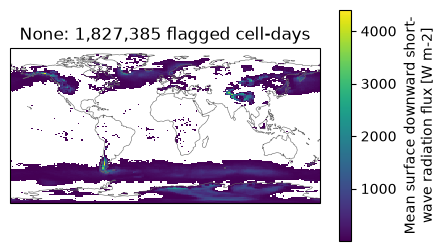

INFO:srm.qa_flags:  flag loop 4/5 completed in 48.4s
INFO:srm.qa_flags:Running flag loop 5/5: trend distortion flag...
INFO:srm.qa_flags:scenario comparison: g6_1p5k_ssp245
INFO:srm.qa_flags:variable: tas


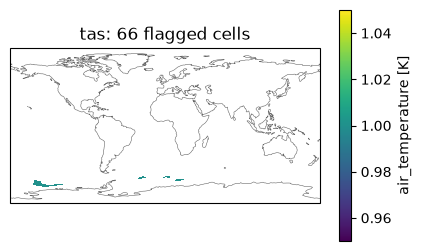

INFO:srm.qa_flags:No flags found.
INFO:srm.qa_flags:UKESM1-1-LL_tas_ssp245_r2i1p1f2_bcsd
INFO:srm.qa_flags:UKESM1-1-LL_tas_g6_1p5k_r2i1p1f2_bcsd
INFO:srm.qa_flags:variable: tas
INFO:srm.qa_flags:No flags found.
INFO:srm.qa_flags:No flags found.
INFO:srm.qa_flags:UKESM1-1-LL_tas_ssp245_r2i1p1f2_qdmsd
INFO:srm.qa_flags:UKESM1-1-LL_tas_g6_1p5k_r2i1p1f2_qdmsd
INFO:srm.qa_flags:variable: tasmax


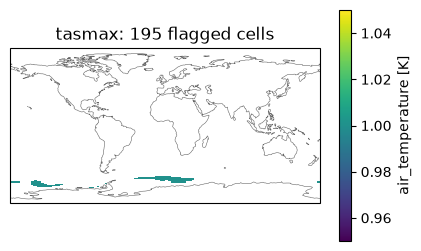

INFO:srm.qa_flags:No flags found.
INFO:srm.qa_flags:UKESM1-1-LL_tasmax_ssp245_r2i1p1f2_bcsd
INFO:srm.qa_flags:UKESM1-1-LL_tasmax_g6_1p5k_r2i1p1f2_bcsd
INFO:srm.qa_flags:variable: tasmax
INFO:srm.qa_flags:No flags found.
INFO:srm.qa_flags:No flags found.
INFO:srm.qa_flags:UKESM1-1-LL_tasmax_ssp245_r2i1p1f2_qdmsd
INFO:srm.qa_flags:UKESM1-1-LL_tasmax_g6_1p5k_r2i1p1f2_qdmsd
INFO:srm.qa_flags:variable: tasmin


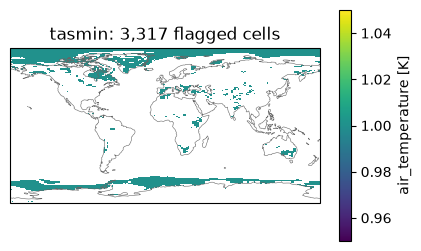

INFO:srm.qa_flags:No flags found.
INFO:srm.qa_flags:UKESM1-1-LL_tasmin_ssp245_r2i1p1f2_bcsd
INFO:srm.qa_flags:UKESM1-1-LL_tasmin_g6_1p5k_r2i1p1f2_bcsd
INFO:srm.qa_flags:variable: tasmin


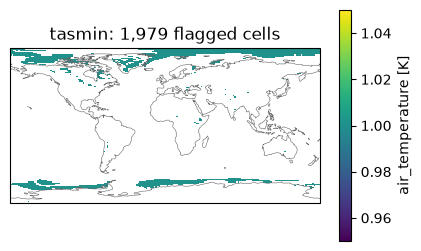

INFO:srm.qa_flags:No flags found.
INFO:srm.qa_flags:UKESM1-1-LL_tasmin_ssp245_r2i1p1f2_qdmsd
INFO:srm.qa_flags:UKESM1-1-LL_tasmin_g6_1p5k_r2i1p1f2_qdmsd
INFO:srm.qa_flags:variable: pr


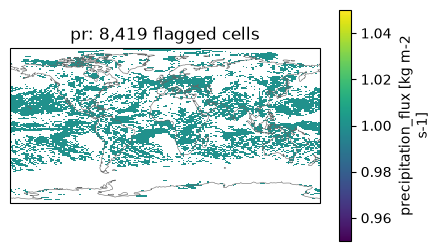

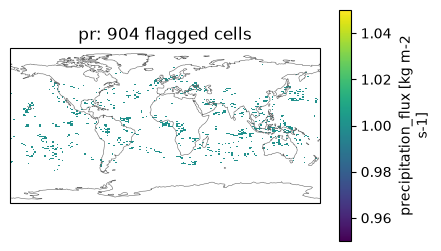

INFO:srm.qa_flags:UKESM1-1-LL_pr_ssp245_r2i1p1f2_bcsd
INFO:srm.qa_flags:UKESM1-1-LL_pr_g6_1p5k_r2i1p1f2_bcsd
INFO:srm.qa_flags:variable: pr


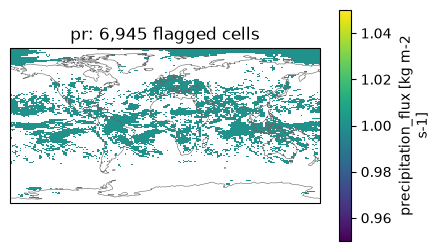

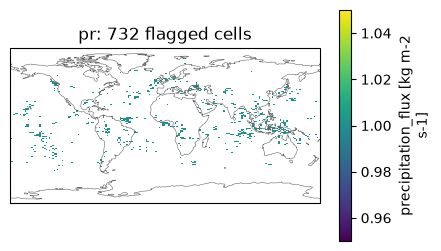

INFO:srm.qa_flags:UKESM1-1-LL_pr_ssp245_r2i1p1f2_qdmsd
INFO:srm.qa_flags:UKESM1-1-LL_pr_g6_1p5k_r2i1p1f2_qdmsd
INFO:srm.qa_flags:variable: rsds


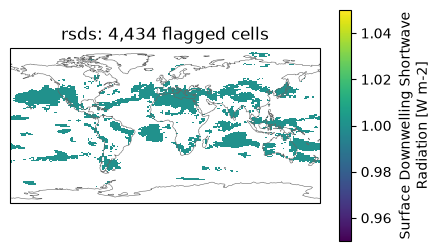

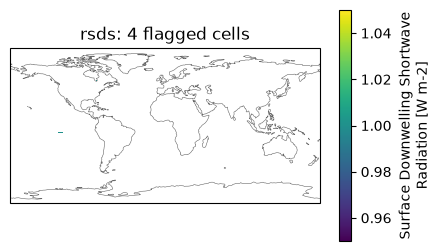

INFO:srm.qa_flags:UKESM1-1-LL_rsds_ssp245_r2i1p1f2_bcsd
INFO:srm.qa_flags:UKESM1-1-LL_rsds_g6_1p5k_r2i1p1f2_bcsd
INFO:srm.qa_flags:variable: rsds


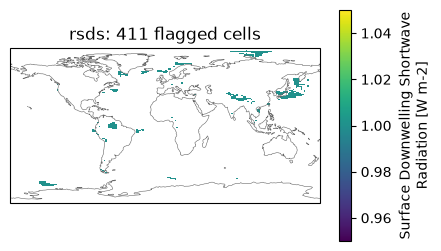

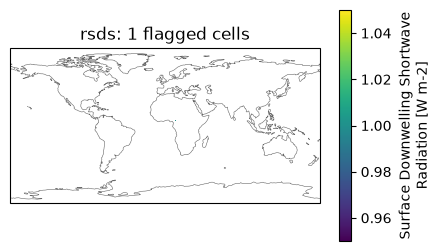

INFO:srm.qa_flags:UKESM1-1-LL_rsds_ssp245_r2i1p1f2_qdmsd
INFO:srm.qa_flags:UKESM1-1-LL_rsds_g6_1p5k_r2i1p1f2_qdmsd
INFO:srm.qa_flags:scenario comparison: ssp245_hist
INFO:srm.qa_flags:variable: tas


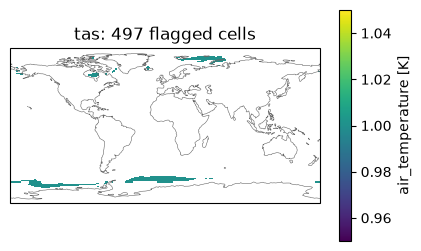

INFO:srm.qa_flags:No flags found.
INFO:srm.qa_flags:UKESM1-1-LL_tas_historical_u-by791_bcsd
INFO:srm.qa_flags:UKESM1-1-LL_tas_ssp245_r2i1p1f2_bcsd
INFO:srm.qa_flags:variable: tas
INFO:srm.qa_flags:No flags found.
INFO:srm.qa_flags:No flags found.
INFO:srm.qa_flags:UKESM1-1-LL_tas_historical_u-by791_qdmsd
INFO:srm.qa_flags:UKESM1-1-LL_tas_ssp245_r2i1p1f2_qdmsd
INFO:srm.qa_flags:variable: tasmax


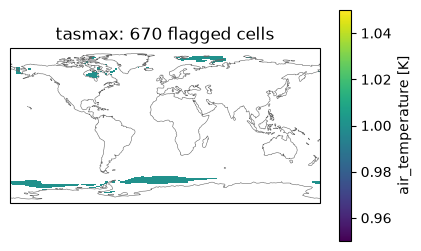

INFO:srm.qa_flags:No flags found.
INFO:srm.qa_flags:UKESM1-1-LL_tasmax_historical_u-by791_bcsd
INFO:srm.qa_flags:UKESM1-1-LL_tasmax_ssp245_r2i1p1f2_bcsd
INFO:srm.qa_flags:variable: tasmax
INFO:srm.qa_flags:No flags found.
INFO:srm.qa_flags:No flags found.
INFO:srm.qa_flags:UKESM1-1-LL_tasmax_historical_u-by791_qdmsd
INFO:srm.qa_flags:UKESM1-1-LL_tasmax_ssp245_r2i1p1f2_qdmsd
INFO:srm.qa_flags:variable: tasmin


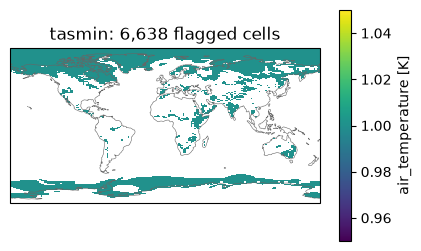

INFO:srm.qa_flags:No flags found.
INFO:srm.qa_flags:UKESM1-1-LL_tasmin_historical_u-by791_bcsd
INFO:srm.qa_flags:UKESM1-1-LL_tasmin_ssp245_r2i1p1f2_bcsd
INFO:srm.qa_flags:variable: tasmin


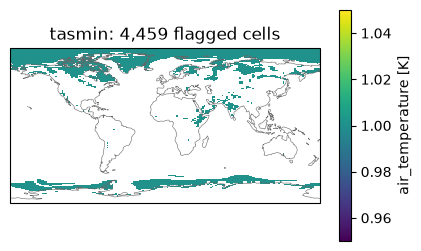

INFO:srm.qa_flags:No flags found.
INFO:srm.qa_flags:UKESM1-1-LL_tasmin_historical_u-by791_qdmsd
INFO:srm.qa_flags:UKESM1-1-LL_tasmin_ssp245_r2i1p1f2_qdmsd
INFO:srm.qa_flags:variable: pr


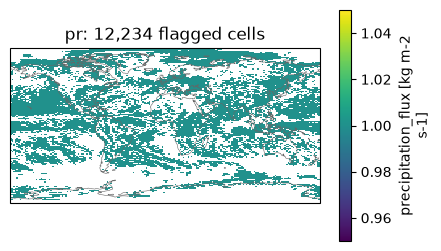

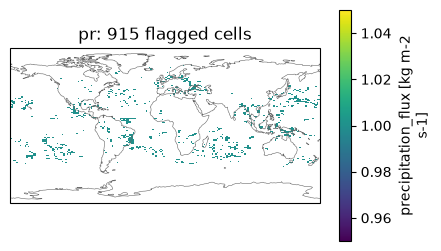

INFO:srm.qa_flags:UKESM1-1-LL_pr_historical_u-by791_bcsd
INFO:srm.qa_flags:UKESM1-1-LL_pr_ssp245_r2i1p1f2_bcsd
INFO:srm.qa_flags:variable: pr


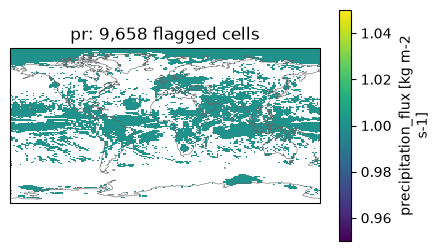

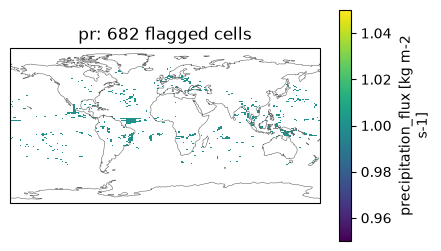

INFO:srm.qa_flags:UKESM1-1-LL_pr_historical_u-by791_qdmsd
INFO:srm.qa_flags:UKESM1-1-LL_pr_ssp245_r2i1p1f2_qdmsd
INFO:srm.qa_flags:variable: rsds


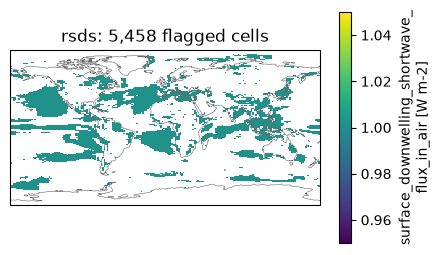

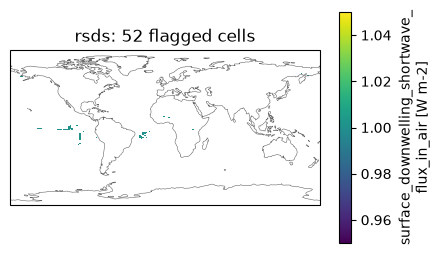

INFO:srm.qa_flags:UKESM1-1-LL_rsds_historical_u-by791_bcsd
INFO:srm.qa_flags:UKESM1-1-LL_rsds_ssp245_r2i1p1f2_bcsd
INFO:srm.qa_flags:variable: rsds


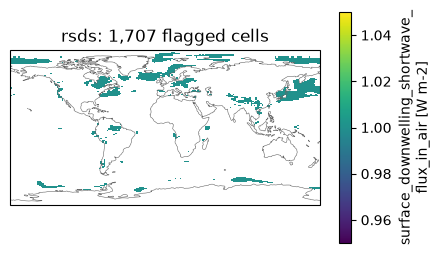

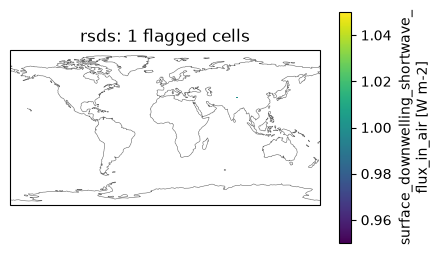

INFO:srm.qa_flags:UKESM1-1-LL_rsds_historical_u-by791_qdmsd
INFO:srm.qa_flags:UKESM1-1-LL_rsds_ssp245_r2i1p1f2_qdmsd
INFO:srm.qa_flags:scenario comparison: g6_1p5k_hist
INFO:srm.qa_flags:variable: tas


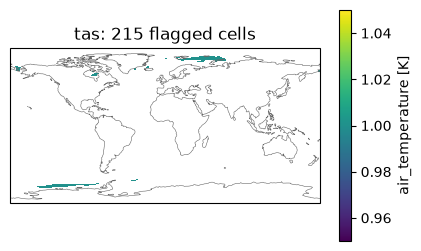

INFO:srm.qa_flags:No flags found.
INFO:srm.qa_flags:UKESM1-1-LL_tas_historical_u-by791_bcsd
INFO:srm.qa_flags:UKESM1-1-LL_tas_g6_1p5k_r2i1p1f2_bcsd
INFO:srm.qa_flags:variable: tas
INFO:srm.qa_flags:No flags found.
INFO:srm.qa_flags:No flags found.
INFO:srm.qa_flags:UKESM1-1-LL_tas_historical_u-by791_qdmsd
INFO:srm.qa_flags:UKESM1-1-LL_tas_g6_1p5k_r2i1p1f2_qdmsd
INFO:srm.qa_flags:variable: tasmax


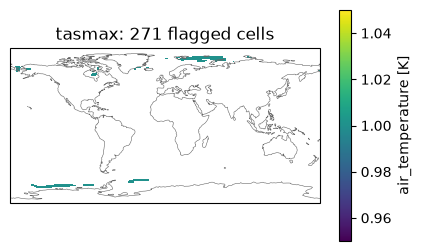

INFO:srm.qa_flags:No flags found.
INFO:srm.qa_flags:UKESM1-1-LL_tasmax_historical_u-by791_bcsd
INFO:srm.qa_flags:UKESM1-1-LL_tasmax_g6_1p5k_r2i1p1f2_bcsd
INFO:srm.qa_flags:variable: tasmax
INFO:srm.qa_flags:No flags found.
INFO:srm.qa_flags:No flags found.
INFO:srm.qa_flags:UKESM1-1-LL_tasmax_historical_u-by791_qdmsd
INFO:srm.qa_flags:UKESM1-1-LL_tasmax_g6_1p5k_r2i1p1f2_qdmsd
INFO:srm.qa_flags:variable: tasmin


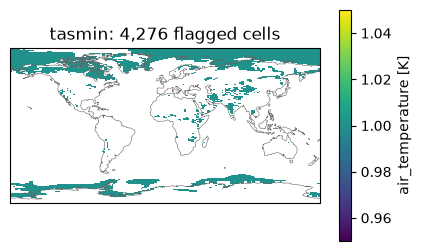

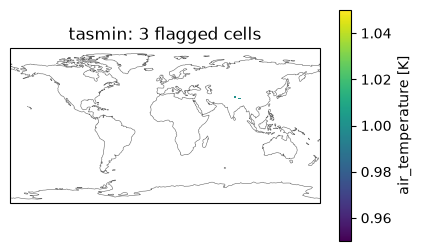

INFO:srm.qa_flags:UKESM1-1-LL_tasmin_historical_u-by791_bcsd
INFO:srm.qa_flags:UKESM1-1-LL_tasmin_g6_1p5k_r2i1p1f2_bcsd
INFO:srm.qa_flags:variable: tasmin


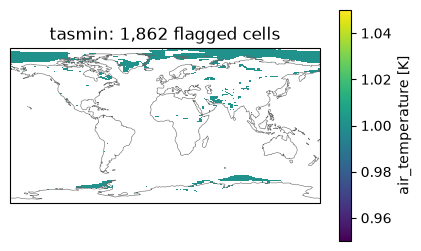

INFO:srm.qa_flags:No flags found.
INFO:srm.qa_flags:UKESM1-1-LL_tasmin_historical_u-by791_qdmsd
INFO:srm.qa_flags:UKESM1-1-LL_tasmin_g6_1p5k_r2i1p1f2_qdmsd
INFO:srm.qa_flags:variable: pr


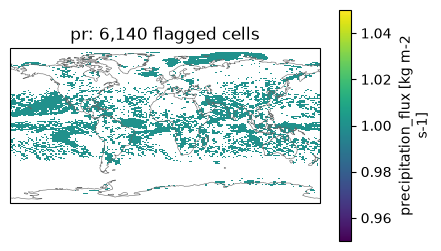

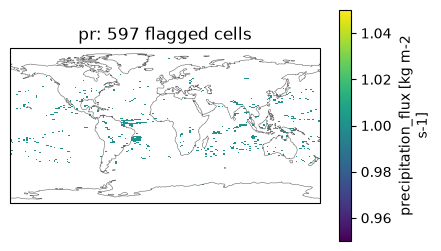

INFO:srm.qa_flags:UKESM1-1-LL_pr_historical_u-by791_bcsd
INFO:srm.qa_flags:UKESM1-1-LL_pr_g6_1p5k_r2i1p1f2_bcsd
INFO:srm.qa_flags:variable: pr


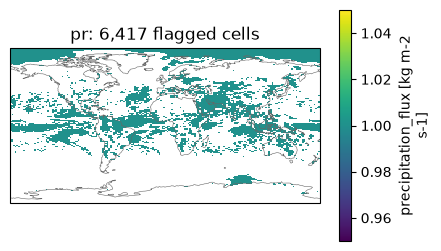

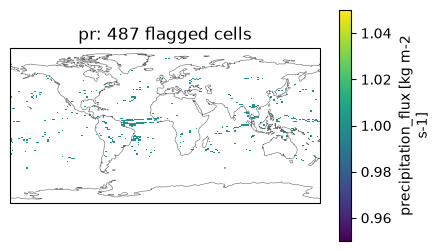

INFO:srm.qa_flags:UKESM1-1-LL_pr_historical_u-by791_qdmsd
INFO:srm.qa_flags:UKESM1-1-LL_pr_g6_1p5k_r2i1p1f2_qdmsd
INFO:srm.qa_flags:variable: rsds


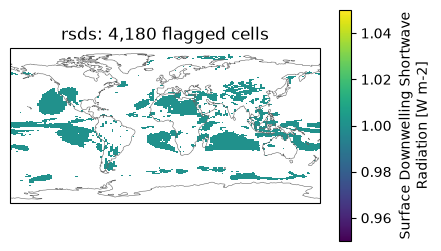

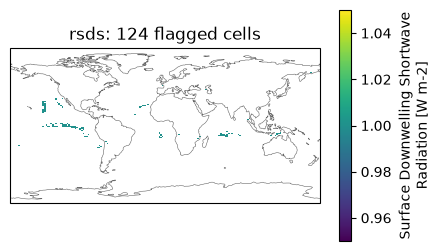

INFO:srm.qa_flags:UKESM1-1-LL_rsds_historical_u-by791_bcsd
INFO:srm.qa_flags:UKESM1-1-LL_rsds_g6_1p5k_r2i1p1f2_bcsd
INFO:srm.qa_flags:variable: rsds


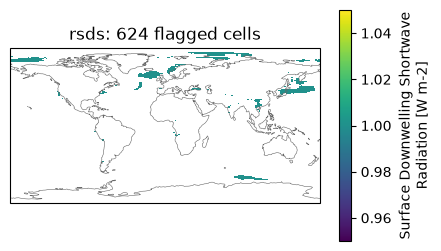

INFO:srm.qa_flags:No flags found.
INFO:srm.qa_flags:UKESM1-1-LL_rsds_historical_u-by791_qdmsd
INFO:srm.qa_flags:UKESM1-1-LL_rsds_g6_1p5k_r2i1p1f2_qdmsd
INFO:srm.qa_flags:scenario comparison: g6_1p5k_end_g6_1p5k
INFO:srm.qa_flags:variable: tas
INFO:srm.qa_flags:variable: tas
INFO:srm.qa_flags:variable: tasmax
INFO:srm.qa_flags:variable: tasmax
INFO:srm.qa_flags:variable: tasmin
INFO:srm.qa_flags:variable: tasmin
INFO:srm.qa_flags:variable: pr
INFO:srm.qa_flags:variable: pr
INFO:srm.qa_flags:variable: rsds
INFO:srm.qa_flags:variable: rsds
INFO:srm.qa_flags:  flag loop 5/5 completed in 652.1s
INFO:srm.qa_flags:calculate_all_flags total time: 1105.1s
INFO:srm.qa_flags:  flags on coarse debiased data for UKESM1-1-LL completed in 1105.1s
INFO:srm.qa_flags:  flags on coarse debiased data (all gcms) completed in 3862.7s
INFO:srm.qa_flags:run_step2 total time: 3940.9s


In [8]:
run_step2(
    variables=VARIABLES,
    gcms=GCMS,
    methods=METHODS,
    branch=BRANCH,
    root_dir=ROOT_DIR,
    store_subset_id=STORE_SUBSET_ID,
    bucket=BUCKET,
    prefix=PREFIX,
    plot_flag_maps=True,
    verbose=True,
    mode="debiased_coarse_only",
)

In [9]:
cluster.shutdown()

[2026-09-09 00:17:57,284][INFO    ][coiled] Cluster 2024676 deleted successfully.
INFO:coiled:Cluster 2024676 deleted successfully.


# Option 2: go through each step one at a time (just for downscaled, not including debiased coarse in this demo)

In [ ]:
IS_DOWNSCALED = True

### A. Define what data arrays exist to traverse

In [ ]:
[
    trees,
    tags,
    gcms_np,
    scenarios_np,
    variables_np,
    tags_np,
    methods_np,
    debiased_coarse_flags_np,
] = discover_leaves(
    gcms=GCMS,
    branch=BRANCH,
    root_dir=ROOT_DIR,
    store_subset_id=STORE_SUBSET_ID,
    is_downscaled=IS_DOWNSCALED,
)

### B. Generate individual time-varying QA flags

#### 1. global exceedances

In [ ]:
%%time
run_flag_loop(
    tags=tags,
    trees=trees,
    bucket=BUCKET,
    prefix=PREFIX,
    flag_name="outside_global_plausible_range",
    compute_flag=lambda da, var: flag_global_exceedances(da=da, var=var),
    write_mode="a",
    is_downscaled=IS_DOWNSCALED,
)

# with plotting ~14.5 mins

#### 2. Outliers based on observations

##### 2a. Calculate outlier bounds

In [ ]:
# Loading thresholds output from step 1 notebook
store = DIR_QA_FLAG_CONSTANT_INPUTS + "doy_obs_thresholds_global.zarr"
combined = xr.open_zarr(store)

In [ ]:
def _split(ds, suffix):
    names = [v for v in ds.data_vars if v.endswith(suffix)]
    return ds[names].rename({v: v[: -len(suffix)] for v in names})


obs_max = _split(combined, "_max")
obs_min = _split(combined, "_min")
obs_max_std = _split(combined, "_max_std")
obs_min_std = _split(combined, "_min_std")

In [ ]:
[outlier_thresh_low, outlier_thresh_high] = calculate_thresholds(
    obs_max, obs_min, obs_max_std, obs_min_std
)

##### 2b. Traverse dataset and save flags

In [ ]:
outlier_thresh_low_annual = outlier_thresh_low.min(dim="dayofyear")
outlier_thresh_high_annual = outlier_thresh_high.max(dim="dayofyear")

In [ ]:
run_flag_loop(
    tags=tags,
    trees=trees,
    flag_name="annual_outlier_flag",
    compute_flag=lambda da, var: flag_outliers(
        da=da,
        outlier_thresh_low=outlier_thresh_low_annual[var],
        outlier_thresh_high=outlier_thresh_high_annual[var],
        timescale="annual",
    ),
    bucket=BUCKET,
    prefix=PREFIX,
    write_mode="a",
    is_downscaled=IS_DOWNSCALED,
)

#### 3. rsds-specific latitude check

In [ ]:
def load_rsds_lims(
    key: str = "zonal_doy_max_rsds",
    fpath: str = DIR_QA_FLAG_CONSTANT_INPUTS + "zonal_doy_max_rsds.zarr",
) -> xr.DataArray:
    return xr.open_zarr(fpath, group=key)["data"].load()

In [ ]:
zonal_doy_max_rsds = load_rsds_lims()

In [ ]:
run_flag_loop(
    tags=tags,
    trees=trees,
    flag_name="rsds_max_exceeded",
    compute_flag=lambda da, var: flag_rsds_above_max(da=da, zonal_doy_max_rsds=zonal_doy_max_rsds),
    var_filter=["rsds"],
    bucket=BUCKET,
    prefix=PREFIX,
    write_mode="a",
    is_downscaled=IS_DOWNSCALED,
)

#### 4. temperature inconsistencies

In [ ]:
from srm.qa_flags import run_flag_loop_temperature_inconsistencies

In [ ]:
run_flag_loop_temperature_inconsistencies(
    tags=tags,
    trees=trees,
    flag_name="temperature_inconsistency",
    bucket=BUCKET,
    prefix=PREFIX,
    is_downscaled=IS_DOWNSCALED,
    plot=True,
    save_plots=False,
)

### C. Generate flags that are constant over time

In [ ]:
from srm.qa_flags import (
    calculate_trend_distortion_flags,
)

In [ ]:
calculate_trend_distortion_flags(
    trees=trees,
    gcms=GCMS,
    variables=VARIABLES,
    methods=METHODS,
    tags_np=tags_np,
    gcms_np=gcms_np,
    scenarios_np=scenarios_np,
    variables_np=variables_np,
    methods_np=methods_np,
    bucket=BUCKET,
    prefix=PREFIX,
    is_downscaled=IS_DOWNSCALED,
    plot=True,
    save_plots=False,
)

In [ ]:
if cluster is not None:
    cluster.shutdown()
else:
    print("no cluster was created (cached run); nothing to shut down")

### D. Read in flags

In [ ]:
from srm.qa_flags import get_intermediate_flags

gcm = "CESM2-WACCM6"
var = "rsds"
scenario = "ssp245"
ens = "008"
method = "qdmsd"

tag = f"{gcm}_{var}_{scenario}_{ens}_{method}"
flag_ds = get_intermediate_flags(tag=tag, bucket=BUCKET, prefix=PREFIX)

In [ ]:
fig, axes = plt.subplots(nrows=2, ncols=2)
flag_frac = flag_ds["outside_global_plausible_range"].mean(dim="time")
flag_frac.where(flag_frac > 0).plot(ax=axes[0, 0])
flag_frac = flag_ds["rsds_max_exceeded"].mean(dim="time")
flag_frac.where(flag_frac > 0).plot(ax=axes[0, 1])
flag_frac = flag_ds["annual_outlier_flag"].mean(dim="time")
flag_frac.where(flag_frac > 0).plot(ax=axes[1, 0])
plt.tight_layout()

In [ ]:
flag_ds["rsds_max_exceeded"].sum(dim="time").plot()
plt.plot([28.5], [-29.6], "xr")